In [55]:
from mpi4py import MPI
import gmsh
import numpy as np
from scipy.spatial import cKDTree
import pyvista as pv
from dolfinx import plot

N_ref = 8

Lx, Ly = 1.0, 1.0
y_start, y_end = 0.0, 1.0
x_start, x_end = 0.0, 1.0

#REFERENCE SOLUTION
from dolfinx import mesh, fem
import ufl
import numpy as np

# ---------------------------------------------------------------------
# 1. Mesh and interface tags (similar to Γ tagging in the workshop)
# ---------------------------------------------------------------------
# Load Gmsh mesh (2D bulk Ω + 1D interface Γ)
from dolfinx.io import gmsh as gmshio
ref = N_ref
filename = f"regular_mesh_with_fracture_{ref}.msh"
msh, cell_markers, facet_markers = gmshio.read_from_msh(filename, MPI.COMM_WORLD, 0, gdim=2)[0:3]

tdim = msh.topology.dim  # 2
fdim = tdim - 1             # 1

lc = 1.0/ (2**ref)          # mesh size
h = lc

# Find all facets tagged as Gamma (tag=2)
omega = msh
gamma_entities = facet_markers.find(2)

# Create a submesh for Γ (same as gamma in the JSDokken example)
gamma, gamma_to_omega, gamma_vertex_to_omega = mesh.create_submesh(omega, fdim, gamma_entities)[0:3]

# Define interface tag ID (as defined in Gmsh)
Gamma_tag = 2  # <-- replace with your actual tag ID for the interface Γ

# ---------------------------------------------------------------------
# 2. Function spaces
# ---------------------------------------------------------------------
order = 1
V_m = fem.functionspace(omega, ("Lagrange", order))  # bulk Ω
V_f = fem.functionspace(gamma, ("Lagrange", order))   # interface Γ
V_l = fem.functionspace(gamma, ("Lagrange", order))   # multiplier space on Γ
W = ufl.MixedFunctionSpace(V_m, V_f, V_l)

# ---------------------------------------------------------------------
# 3. Trial and Test functions
# ---------------------------------------------------------------------
phi, psi, mu = ufl.TestFunctions(W)
dp_m, dp_f, dl = ufl.TrialFunctions(W)
p_m = fem.Function(V_m, name="p_m")
p_f = fem.Function(V_f, name="p_f")
lmbd = fem.Function(V_l, name="lmbd")

# ---------------------------------------------------------------------
# 4. Spatial coordinates and given data
# ---------------------------------------------------------------------
x = ufl.SpatialCoordinate(msh)
# f_m = fem.Constant(msh, 0.0)
# f_m = -x[1]**2 -2*x[0]**2
def f_callable(x):
    return -x[1]
f_m = fem.Function(V_m)
f_m.interpolate(f_callable)

# f_f = fem.Constant(msh, 0.0)
f_f = fem.Function(V_f)

# set value
f_f.x.array[:] = 0.0

# k_m = fem.Constant(omega, 1.0)
k_m = fem.Function(V_m)
# k_m.x.array[:] = 1.0
def k_callable(x):
    # x is array with shape (gdim, N). compute scalar per point, return shape (1,N)
    vals = x[0]*2+1
    # vals = x[0]*0+1
    return vals[np.newaxis, :]

k_m.interpolate(k_callable)

# k_f = fem.Constant(gamma, 10.0)
k_f = fem.Function(V_f)
k_f.x.array[:] = 10.0

dx = ufl.Measure("dx", domain=omega)
dS_omega = ufl.Measure("dS", domain=omega)   # interior facets of omega
# ds = dS_omega(Gamma_tag)
# ds = ufl.Measure("ds", domain=omega, subdomain_data=facet_markers, subdomain_id=Gamma_tag)
ds = ufl.Measure("ds", domain=omega, subdomain_data=facet_markers, subdomain_id=Gamma_tag) #Gamma is interior boundary
dx_f = ufl.Measure("dx", domain=gamma)

# Compute bounding box to locate sides
coords = omega.geometry.x
xx = coords[:, 0]
yy = coords[:, 1]

xmin, xmax = xx.min(), xx.max()
ymin, ymax = yy.min(), yy.max()

# Tolerance for side detection
tol = 1e-10 * max(xmax - xmin, ymax - ymin)

# Locate boundary facets for bottom (y = ymin) and top (y = ymax)
bottom_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymin, atol=tol)
)
top_facets = mesh.locate_entities_boundary(
    omega, fdim, lambda x: np.isclose(x[1], ymax, atol=tol)
)

# Give them integer tags: 1 = bottom, 2 = top
indices = np.concatenate([bottom_facets, top_facets]).astype(np.int32)
values = np.concatenate([
    np.full(bottom_facets.shape, 10, dtype=np.int32),  # bottom tag = 1
    np.full(top_facets.shape,    20, dtype=np.int32),  # top tag    = 2
])

neumann_tags = mesh.meshtags(omega, fdim, indices, values)

# Boundary measure for these Neumann parts
dsN = ufl.Measure("ds", domain=omega)
# dsN = ufl.Measure("ds", domain=omega, subdomain_data=neumann_tags)
# ds_Omega = ufl.Measure("ds", domain=Omega)

# Neumann data: k ∂p/∂n = g on boundary
# g_bottom = fem.Constant(omega, 2.0)   # bottom = 2
# g_top    = fem.Constant(omega, -1.0)  # top    = -1

g_N = ufl.conditional(
    ufl.lt(abs(x[1] - ymax), tol),
    -1.0,                                # top
    ufl.conditional(
        ufl.lt(abs(x[1] - ymin), tol),
        2.0,                           # bottom
        0.0                             # elsewhere
    ),
)

# ---------------------------------------------------------------------
# 5. Weak formulations
# ---------------------------------------------------------------------

# --- Bulk domain Ω ---------------------------------------------------
a_m0 = ufl.inner(k_m * ufl.grad(p_m), ufl.grad(phi)) * dx
a_m1 = -lmbd * phi * ds 
# a_m1 = -ufl.avg(lmbd) * phi * ds
a_m = a_m0 + a_m1
# L_m = f_m * phi * dx
L_m = (
    f_m * phi * dx

    # - g_bottom * phi * dsN(10)   # bottom boundary (tag 1)
    # - g_top * phi * dsN(20)      # top boundary (tag 2)
)
L_m -= g_N * phi * dsN


# --- Interface Γ -----------------------------------------------------
a_f0 = ufl.inner(k_f * ufl.grad(p_f), ufl.grad(psi)) * ds
a_f1 = lmbd * psi * ds
a_f = a_f0 + a_f1
L_f = f_f * psi * ds

# --- Lagrange multiplier (constraint tr(p_m) = p_f) ------------------
a_l0 = p_m * mu * ds
a_l1 = -p_f * mu * ds
a_l = a_l0 + a_l1
L_l = fem.Constant(msh, 0.0) * mu * ds

# ---------------------------------------------------------------------
# 6. Combine interface weak form
# ---------------------------------------------------------------------
a_gamma = a_f + a_l
L_gamma = L_f + L_l

F = a_m - L_m + a_gamma - L_gamma
residual = ufl.extract_blocks(F)

jac = ufl.derivative(F, p_m, dp_m) + ufl.derivative(F, p_f, dp_f) + ufl.derivative(F, lmbd, dl)
J = ufl.extract_blocks(jac)

# Locate dofs on each side
left_dofs   = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmin, atol=tol))
right_dofs  = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[0], xmax, atol=tol))
bottom_dofs = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[1], ymin, atol=tol))
top_dofs    = fem.locate_dofs_geometrical(V_m, lambda x: np.isclose(x[1], ymax, atol=tol))

# Union of all boundary dofs for which we enforce a value
# all_dofs = np.unique(np.concatenate([left_dofs, right_dofs, bottom_dofs, top_dofs]))
all_dofs = np.unique(np.concatenate([left_dofs, right_dofs]))

# Build a Function-valued BC so we can assign side-dependent values
p_m_bc = fem.Function(V_m)
# p_m_bc.x.array[:] = 1.0  # default 0 (bottom + right)
p_m_bc.x.array[left_dofs] = 1.0
p_m_bc.x.array[right_dofs]  = 4.0

# One BC object over the union of dofs with piecewise values
bc_pm = fem.dirichletbc(p_m_bc, all_dofs)

# tolerance scaled to Γ
tol_g = 1e-10 * np.max(np.ptp(gamma.geometry.x, axis=0))

# locate dofs at each tip
tip1_dofs = fem.locate_dofs_geometrical(
    V_f,
    lambda x: np.logical_and(np.isclose(x[0], x_start, atol=tol_g),
                             np.isclose(x[1], y_start, atol=tol_g))
)
tip2_dofs = fem.locate_dofs_geometrical(
    V_f,
    lambda x: np.logical_and(np.isclose(x[0], x_end, atol=tol_g),
                             np.isclose(x[1], y_end, atol=tol_g))
)
# OR (ii) Different values at the two tips -> two BC objects
both_tips = np.unique(np.concatenate([tip1_dofs, tip2_dofs]))

# one Function-valued BC with piecewise values
pf_fun = fem.Function(V_f)
# pf_fun.x.array[:] = 0.0
pf_fun.x.array[tip1_dofs] = 1   # e.g. 1.0
pf_fun.x.array[tip2_dofs] = 4   # e.g. 3.0

bc_pf = fem.dirichletbc(pf_fun, both_tips)

# add it
bcs = [bc_pm, bc_pf]

print("DOFs in p_m:", p_m.function_space.dofmap.index_map.size_global)
print("DOFs in p_f:", p_f.function_space.dofmap.index_map.size_global)
print("DOFs in λ:", lmbd.function_space.dofmap.index_map.size_global)
total_dofs = (
    p_m.function_space.dofmap.index_map.size_global
    + p_f.function_space.dofmap.index_map.size_global
    + lmbd.function_space.dofmap.index_map.size_global
)
print("Total DOFs:", total_dofs)

from dolfinx.fem import petsc
entity_maps = [gamma_to_omega]

nlp = petsc.NonlinearProblem(
    residual,
    u=[p_m, p_f, lmbd],
    J=J,
    bcs=bcs,
    entity_maps=entity_maps,
    petsc_options={
        "snes_monitor": None,
        "snes_max_it": 200,  # default is 50, set your own limit
        "ksp_type": "preonly",
        "pc_type": "lu",
        "pc_factor_mat_solver_type": "mumps",
        "mat_mumps_icntl_14": 120,
        "ksp_error_if_not_converged": True,
        "snes_error_if_not_converged": True,
    },
    petsc_options_prefix="pmix_",
)
max_iterations = 25
normed_diff = 0
tol = 1e-5

nlp.solve()
iterations = nlp.solver.getIterationNumber()
print(f"Converged in {iterations} Newton iterations")

p_m_exact = p_m
p_f_exact = p_f
lmbd_exact = lmbd

Info    : Reading 'regular_mesh_with_fracture_8.msh'...
Info    : 590337 entities
Info    : 66049 nodes
Info    : 590337 elements
Info    : Done reading 'regular_mesh_with_fracture_8.msh'                                                        
DOFs in p_m: 66049
DOFs in p_f: 257
DOFs in λ: 257
Total DOFs: 66563
  0 SNES Function norm 7.466387323725e+03
  1 SNES Function norm 4.484368563676e-10
Converged in 1 Newton iterations


In [56]:
from dolfinx.io import XDMFFile
import pathlib

outdir = pathlib.Path("result_conforming_regular2")
outdir.mkdir(parents=True, exist_ok=True)

from dolfinx.io import XDMFFile

# ------------------------------
# 1) Save bulk field p_m on Ω
# ------------------------------
omega_file = outdir / "omega_finest.xdmf"
with XDMFFile(omega.comm, str(omega_file), "w") as xdmf:
    xdmf.write_mesh(omega)
    xdmf.write_function(p_m_exact)

# ------------------------------
# 2) Save interface fields p_f, λ on Γ
# ------------------------------
gamma_file = outdir / "gamma_finest.xdmf"
with XDMFFile(gamma.comm, str(gamma_file), "w") as xdmf:
    xdmf.write_mesh(gamma)
    xdmf.write_function(p_f_exact)
    xdmf.write_function(lmbd_exact)

Info    : Reading 'regular_mesh_with_fracture_3.msh'...
Info    : 593 entities
Info    : 81 nodes
Info    : 593 elements
Info    : Done reading 'regular_mesh_with_fracture_3.msh'

--- ref = 3 ---
DOFs in p_m: 81
DOFs in p_f: 9
DOFs in λ: 9
Total DOFs: 99
  0 SNES Function norm 2.357303263008e+02
  1 SNES Function norm 3.338172002572e-11
Converged in 1 Newton iterations
7631950.983872225


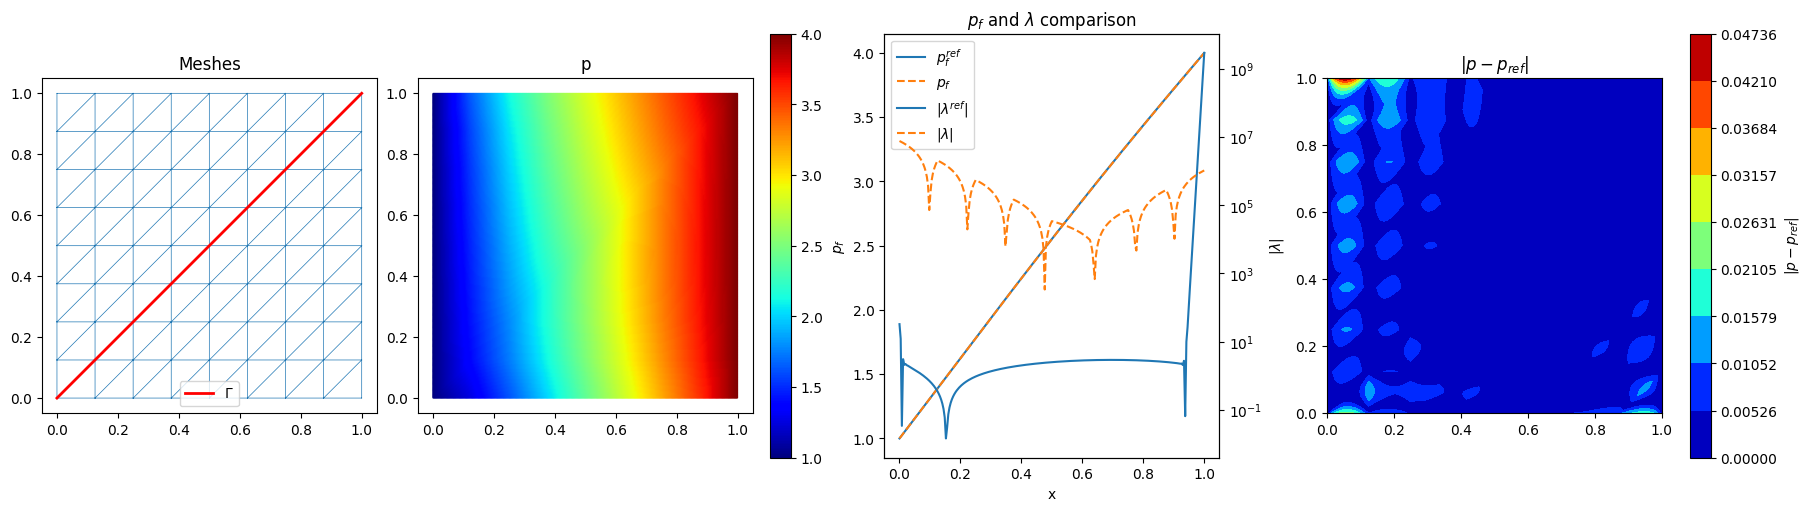

Info    : Reading 'regular_mesh_with_fracture_4.msh'...
Info    : 2337 entities
Info    : 289 nodes
Info    : 2337 elements
Info    : Done reading 'regular_mesh_with_fracture_4.msh'

--- ref = 4 ---
DOFs in p_m: 289
DOFs in p_f: 17
DOFs in λ: 17
Total DOFs: 323
  0 SNES Function norm 4.691078397456e+02
  1 SNES Function norm 1.907746590404e-12
Converged in 1 Newton iterations
406798.43798544654


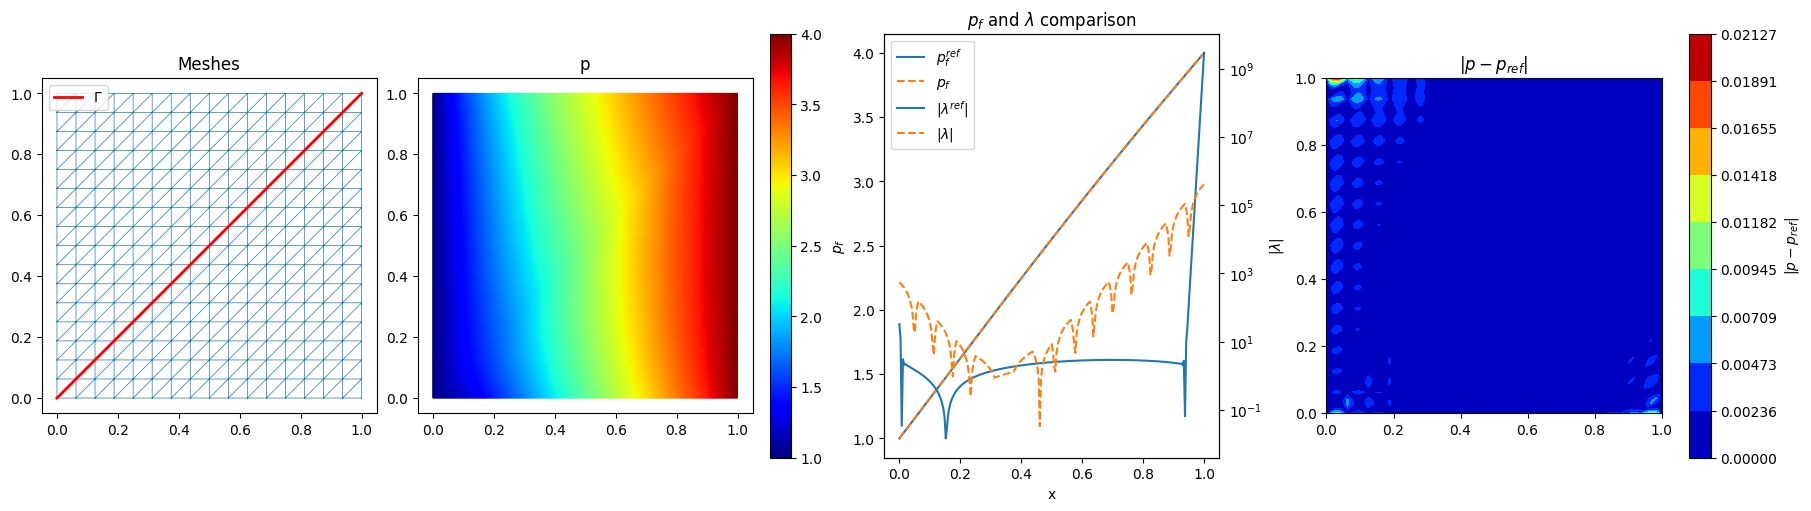

Info    : Reading 'regular_mesh_with_fracture_5.msh'...
Info    : 9281 entities
Info    : 1089 nodes
Info    : 9281 elements
Info    : Done reading 'regular_mesh_with_fracture_5.msh'

--- ref = 5 ---
DOFs in p_m: 1089
DOFs in p_f: 33
DOFs in λ: 33
Total DOFs: 1155
  0 SNES Function norm 9.356563675749e+02
  1 SNES Function norm 1.797641006966e-12
Converged in 1 Newton iterations
97559.06664072262


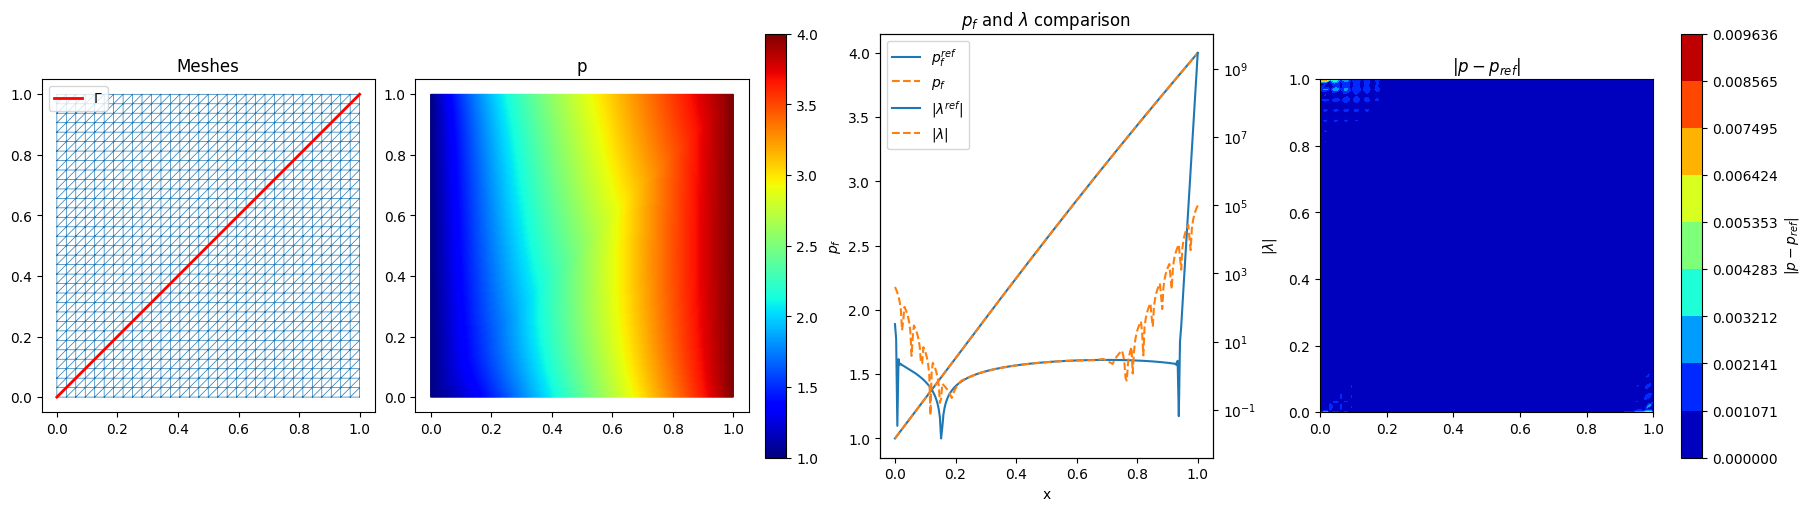

Info    : Reading 'regular_mesh_with_fracture_6.msh'...
Info    : 36993 entities
Info    : 4225 nodes
Info    : 36993 elements
Info    : Done reading 'regular_mesh_with_fracture_6.msh'

--- ref = 6 ---
DOFs in p_m: 4225
DOFs in p_f: 65
DOFs in λ: 65
Total DOFs: 4355
  0 SNES Function norm 1.868645544366e+03
  1 SNES Function norm 3.302110168512e-12
Converged in 1 Newton iterations
11820.745485542997


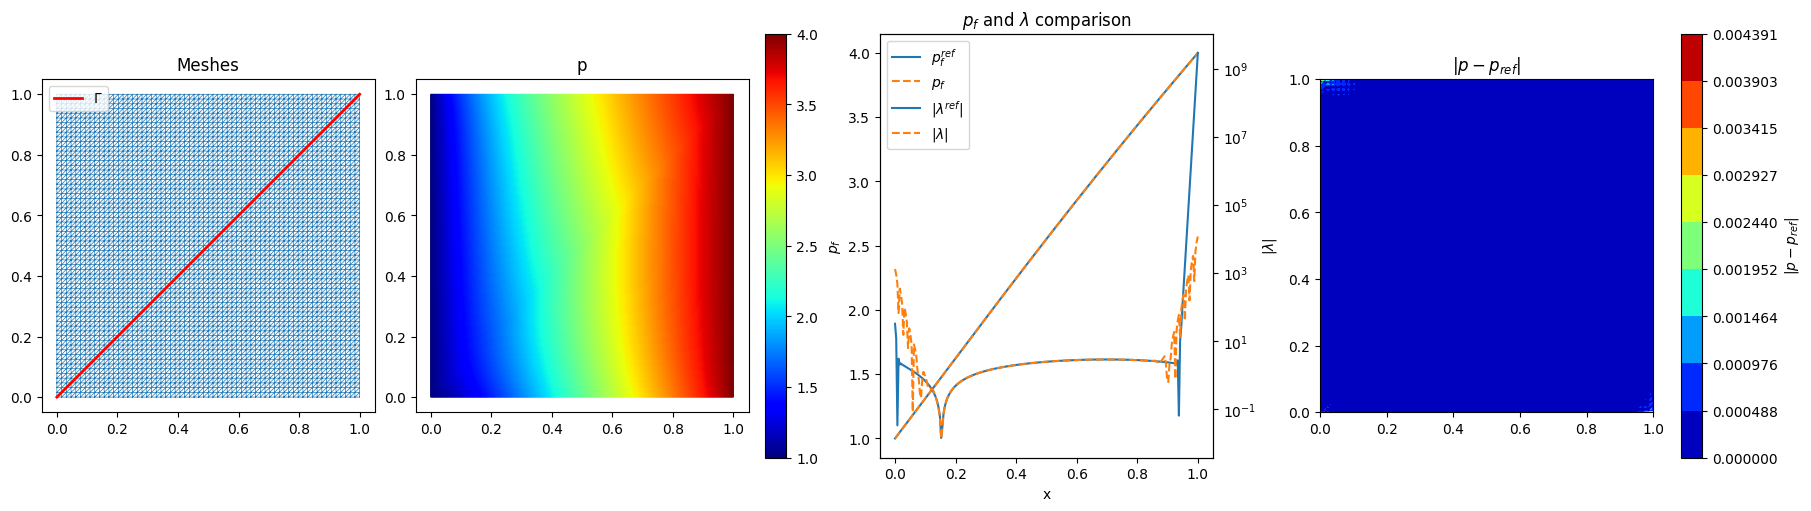

Info    : Reading 'regular_mesh_with_fracture_7.msh'...
Info    : 147713 entities
Info    : 16641 nodes
Info    : 147713 elements
Info    : Done reading 'regular_mesh_with_fracture_7.msh'                                                        

--- ref = 7 ---
DOFs in p_m: 16641
DOFs in p_f: 129
DOFs in λ: 129
Total DOFs: 16899
  0 SNES Function norm 3.734568761663e+03
  1 SNES Function norm 1.094285725257e-11
Converged in 1 Newton iterations
38907.70670382967


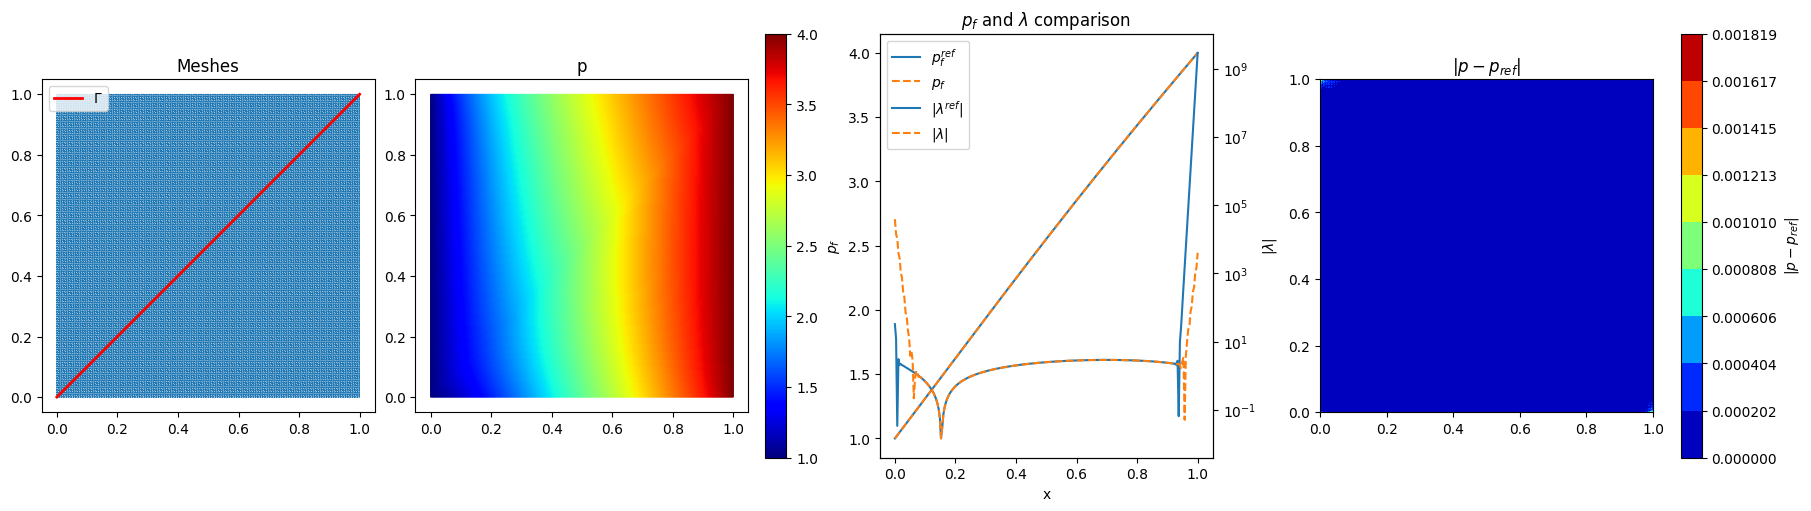

In [57]:
from dolfinx import geometry

def l2_h1_errors(p, p_exact, comm=MPI.COMM_WORLD):
    mesh_fine = p_exact.function_space.mesh
    mesh_coarse = p.function_space.mesh

    tdim = mesh_fine.topology.dim

    # --- Trees on the COARSE mesh (we will evaluate p on the coarse mesh) ---
    bbt_coarse = geometry.bb_tree(mesh_coarse, tdim)
    mid_tree_coarse = geometry.create_midpoint_tree(
        mesh_coarse, tdim,
        np.arange(mesh_coarse.topology.index_map(tdim).size_local, dtype=np.int32)
    )

    # --- Allocate target on the FINE space: p_coarse sampled at fine DoF points ---
    p_coarse_on_exact = fem.Function(p_exact.function_space)

    def eval_p_coarse_on_points(x: np.ndarray) -> np.ndarray:
        gdim, N = x.shape
        if gdim == 2:
            X3 = np.column_stack([x.T, np.zeros(N, dtype=np.float64)])
        elif gdim == 3:
            X3 = x.T.copy()
        else:
            raise ValueError(f"Unsupported geometric dimension gdim={gdim}")

        cands = geometry.compute_collisions_points(bbt_coarse, X3)
        hits = geometry.compute_colliding_cells(mesh_coarse, cands, X3)

        cells = np.full(N, -1, dtype=np.int32)
        for i in range(N):
            li = hits.links(i)
            if len(li) > 0:
                cells[i] = li[0]

        missing = np.where(cells == -1)[0]
        if missing.size > 0:
            nearest = geometry.compute_closest_entity(
                bbt_coarse, mid_tree_coarse, mesh_coarse, X3[missing]
            )
            cells[missing] = nearest

        vals_1d = p.eval(X3, cells)
        return np.asarray(vals_1d, dtype=np.float64).reshape(1, N)

    p_coarse_on_exact.interpolate(eval_p_coarse_on_points)

    dx = ufl.dx(domain=mesh_fine)
    err = p_exact - p_coarse_on_exact

    L2_sq_local = fem.assemble_scalar(fem.form(ufl.inner(err, err) * dx))
    L2_sq = comm.allreduce(L2_sq_local, op=MPI.SUM)

    H1_semi_sq_local = fem.assemble_scalar(
        fem.form(ufl.inner(ufl.grad(err), ufl.grad(err)) * dx)
    )
    H1_semi_sq = comm.allreduce(H1_semi_sq_local, op=MPI.SUM)

    err_L2 = np.sqrt(L2_sq)
    err_H1_semi = np.sqrt(H1_semi_sq)
    err_H1_full = np.sqrt(L2_sq + H1_semi_sq)

    L2_exact_sq_local = fem.assemble_scalar(
        fem.form(ufl.inner(p_coarse_on_exact, p_coarse_on_exact) * dx)
    )
    L2_exact_sq = comm.allreduce(L2_exact_sq_local, op=MPI.SUM)

    H1_semi_exact_sq_local = fem.assemble_scalar(
        fem.form(ufl.inner(ufl.grad(p_coarse_on_exact), ufl.grad(p_coarse_on_exact)) * dx)
    )
    H1_semi_exact_sq = comm.allreduce(H1_semi_exact_sq_local, op=MPI.SUM)

    exact_L2 = np.sqrt(L2_exact_sq)
    exact_H1_semi = np.sqrt(H1_semi_exact_sq)
    exact_H1_full = np.sqrt(L2_exact_sq + H1_semi_exact_sq)

    rel_L2 = err_L2 / exact_L2 if exact_L2 > 0 else (0.0 if err_L2 == 0 else np.inf)
    rel_H1_semi = err_H1_semi / exact_H1_semi if exact_H1_semi > 0 else (0.0 if err_H1_semi == 0 else np.inf)
    rel_H1_full = err_H1_full / exact_H1_full if exact_H1_full > 0 else (0.0 if err_H1_full == 0 else np.inf)

    return {
        "err_L2": err_L2,
        "err_H1_semi": err_H1_semi,
        "err_H1_full": err_H1_full,
        "rel_L2": rel_L2,
        "rel_H1_semi": rel_H1_semi,
        "rel_H1_full": rel_H1_full
    }

from dolfinx import mesh, fem
import ufl
import numpy as np
import matplotlib.tri as mtri
import matplotlib.pyplot as plt
from dolfinx.io import gmsh as gmshio
from dolfinx.fem import petsc
# -----------------------------------------------------------------------------
# Convergence loop
# Assumes you already computed and stored:
#   p_m_exact, p_f_exact, lmbd_exact
# on the finest/reference mesh (typically ref = 7)
#
# Also assumes these lists already exist:
#   h_list
#   L2_fem_list, rL2s_fem_list, H1s_list, rH1s_list
#   L2_fem_list_pf, rL2s_fem_list_pf, H1s_list_pf, rH1s_list_pf
#   L2_fem_list_lmbd, rL2s_fem_list_lmbd, H1s_list_lmbd, rH1s_list_lmbd
#
# Also assumes x_start, y_start, x_end, y_end are already defined
# -----------------------------------------------------------------------------
# --- before the refinement loop (rank 0 only collects) ---
h_list, L2_list, L2_fem_list, rL2_list, rL2s_fem_list, H1s_list, rH1s_list = [], [], [], [], [], [], []
L2_fem_list_pf, rL2s_fem_list_pf, H1s_list_pf, rH1s_list_pf = [], [], [], []
L2_fem_list_lmbd, rL2s_fem_list_lmbd, H1s_list_lmbd, rH1s_list_lmbd = [], [], [], []
for ref in range(3, N_ref):
    # ---------------------------------------------------------------------
    # 1. Mesh and interface tags
    # ---------------------------------------------------------------------
    filename = f"regular_mesh_with_fracture_{ref}.msh"
    msh, cell_markers, facet_markers = gmshio.read_from_msh(
        filename, MPI.COMM_WORLD, 0, gdim=2
    )[0:3]

    tdim = msh.topology.dim
    fdim = tdim - 1

    lc = 1.0 / (2**ref)
    h = lc

    omega = msh
    gamma_entities = facet_markers.find(2)

    gamma, gamma_to_omega, gamma_vertex_to_omega = mesh.create_submesh(
        omega, fdim, gamma_entities
    )[0:3]

    Gamma_tag = 2

    # ---------------------------------------------------------------------
    # 2. Function spaces
    # ---------------------------------------------------------------------
    order = 1
    V_m = fem.functionspace(omega, ("Lagrange", order))
    V_f = fem.functionspace(gamma, ("Lagrange", order))
    V_l = fem.functionspace(gamma, ("Lagrange", order))
    W = ufl.MixedFunctionSpace(V_m, V_f, V_l)

    # ---------------------------------------------------------------------
    # 3. Trial and Test functions
    # ---------------------------------------------------------------------
    phi, psi, mu = ufl.TestFunctions(W)
    dp_m, dp_f, dl = ufl.TrialFunctions(W)

    p_m = fem.Function(V_m, name="p_m")
    p_f = fem.Function(V_f, name="p_f")
    lmbd = fem.Function(V_l, name="lmbd")

    # ---------------------------------------------------------------------
    # 4. Spatial coordinates and given data
    # ---------------------------------------------------------------------
    x = ufl.SpatialCoordinate(msh)

    def f_callable(x):
        return -x[1]

    f_m = fem.Function(V_m)
    f_m.interpolate(f_callable)

    f_f = fem.Function(V_f)
    f_f.x.array[:] = 0.0

    k_m = fem.Function(V_m)

    def k_callable(x):
        vals = x[0] * 2 + 1
        return vals[np.newaxis, :]

    k_m.interpolate(k_callable)

    k_f = fem.Function(V_f)
    k_f.x.array[:] = 10.0

    dx = ufl.Measure("dx", domain=omega)
    dS_omega = ufl.Measure("dS", domain=omega)
    ds = ufl.Measure("ds", domain=omega, subdomain_data=facet_markers, subdomain_id=Gamma_tag)
    dx_f = ufl.Measure("dx", domain=gamma)

    # ---------------------------------------------------------------------
    # 5. Boundary geometry and Neumann data
    # ---------------------------------------------------------------------
    coords = omega.geometry.x
    xx = coords[:, 0]
    yy = coords[:, 1]

    xmin, xmax = xx.min(), xx.max()
    ymin, ymax = yy.min(), yy.max()

    tol = 1e-10 * max(xmax - xmin, ymax - ymin)

    bottom_facets = mesh.locate_entities_boundary(
        omega, fdim, lambda x: np.isclose(x[1], ymin, atol=tol)
    )
    top_facets = mesh.locate_entities_boundary(
        omega, fdim, lambda x: np.isclose(x[1], ymax, atol=tol)
    )

    indices = np.concatenate([bottom_facets, top_facets]).astype(np.int32)
    values = np.concatenate([
        np.full(bottom_facets.shape, 10, dtype=np.int32),
        np.full(top_facets.shape,    20, dtype=np.int32),
    ])

    neumann_tags = mesh.meshtags(omega, fdim, indices, values)

    dsN = ufl.Measure("ds", domain=omega)

    g_N = ufl.conditional(
        ufl.lt(abs(x[1] - ymax), tol),
        -1.0,
        ufl.conditional(
            ufl.lt(abs(x[1] - ymin), tol),
            2.0,
            0.0
        ),
    )

    # ---------------------------------------------------------------------
    # 6. Weak formulations
    # ---------------------------------------------------------------------
    a_m0 = ufl.inner(k_m * ufl.grad(p_m), ufl.grad(phi)) * dx
    a_m1 = -lmbd * phi * ds
    a_m = a_m0 + a_m1

    L_m = f_m * phi * dx
    L_m -= g_N * phi * dsN

    a_f0 = ufl.inner(k_f * ufl.grad(p_f), ufl.grad(psi)) * ds
    a_f1 = lmbd * psi * ds
    a_f = a_f0 + a_f1
    L_f = f_f * psi * ds

    a_l0 = p_m * mu * ds
    a_l1 = -p_f * mu * ds
    a_l = a_l0 + a_l1
    L_l = fem.Constant(msh, 0.0) * mu * ds

    # ---------------------------------------------------------------------
    # 7. Combined residual and Jacobian
    # ---------------------------------------------------------------------
    a_gamma = a_f + a_l
    L_gamma = L_f + L_l

    F = a_m - L_m + a_gamma - L_gamma
    residual = ufl.extract_blocks(F)

    jac = (
        ufl.derivative(F, p_m, dp_m)
        + ufl.derivative(F, p_f, dp_f)
        + ufl.derivative(F, lmbd, dl)
    )
    J = ufl.extract_blocks(jac)

    # ---------------------------------------------------------------------
    # 8. Boundary conditions
    # ---------------------------------------------------------------------
    left_dofs = fem.locate_dofs_geometrical(
        V_m, lambda x: np.isclose(x[0], xmin, atol=tol)
    )
    right_dofs = fem.locate_dofs_geometrical(
        V_m, lambda x: np.isclose(x[0], xmax, atol=tol)
    )
    bottom_dofs = fem.locate_dofs_geometrical(
        V_m, lambda x: np.isclose(x[1], ymin, atol=tol)
    )
    top_dofs = fem.locate_dofs_geometrical(
        V_m, lambda x: np.isclose(x[1], ymax, atol=tol)
    )

    all_dofs = np.unique(np.concatenate([left_dofs, right_dofs]))

    p_m_bc = fem.Function(V_m)
    p_m_bc.x.array[left_dofs] = 1.0
    p_m_bc.x.array[right_dofs] = 4.0
    bc_pm = fem.dirichletbc(p_m_bc, all_dofs)

    tol_g = 1e-10 * np.max(np.ptp(gamma.geometry.x, axis=0))

    tip1_dofs = fem.locate_dofs_geometrical(
        V_f,
        lambda x: np.logical_and(
            np.isclose(x[0], x_start, atol=tol_g),
            np.isclose(x[1], y_start, atol=tol_g)
        )
    )
    tip2_dofs = fem.locate_dofs_geometrical(
        V_f,
        lambda x: np.logical_and(
            np.isclose(x[0], x_end, atol=tol_g),
            np.isclose(x[1], y_end, atol=tol_g)
        )
    )

    both_tips = np.unique(np.concatenate([tip1_dofs, tip2_dofs]))

    pf_fun = fem.Function(V_f)
    pf_fun.x.array[tip1_dofs] = 1.0
    pf_fun.x.array[tip2_dofs] = 4.0

    bc_pf = fem.dirichletbc(pf_fun, both_tips)

    bcs = [bc_pm, bc_pf]

    print(f"\n--- ref = {ref} ---")
    print("DOFs in p_m:", p_m.function_space.dofmap.index_map.size_global)
    print("DOFs in p_f:", p_f.function_space.dofmap.index_map.size_global)
    print("DOFs in λ:", lmbd.function_space.dofmap.index_map.size_global)

    total_dofs = (
        p_m.function_space.dofmap.index_map.size_global
        + p_f.function_space.dofmap.index_map.size_global
        + lmbd.function_space.dofmap.index_map.size_global
    )
    print("Total DOFs:", total_dofs)

    # ---------------------------------------------------------------------
    # 9. Solve
    # ---------------------------------------------------------------------
    entity_maps = [gamma_to_omega]

    nlp = petsc.NonlinearProblem(
        residual,
        u=[p_m, p_f, lmbd],
        J=J,
        bcs=bcs,
        entity_maps=entity_maps,
        petsc_options={
            "snes_monitor": None,
            "snes_max_it": 200,
            "ksp_type": "preonly",
            "pc_type": "lu",
            "pc_factor_mat_solver_type": "mumps",
            "mat_mumps_icntl_14": 120,
            "ksp_error_if_not_converged": True,
            "snes_error_if_not_converged": True,
        },
        petsc_options_prefix="pmix_",
    )

    max_iterations = 25
    normed_diff = 0
    tol_newton = 1e-5

    nlp.solve()
    iterations = nlp.solver.getIterationNumber()
    print(f"Converged in {iterations} Newton iterations")
    print(np.max(np.abs(lmbd.x.array)))

    # ---------------------------------------------------------------------
    # 10. Error computation
    # ---------------------------------------------------------------------
    err_dict = l2_h1_errors(p_m, p_m_exact)
    err_dict_pf = l2_h1_errors(p_f, p_f_exact)
    err_dict_lmbd = l2_h1_errors(lmbd, lmbd_exact)

    err_L2_fem = err_dict["err_L2"]
    err_H1_fem = err_dict["err_H1_semi"]
    rel_L2_fem = err_dict["rel_L2"]
    rel_H1_full_fem = err_dict["rel_H1_semi"]

    err_L2_fem_pf = err_dict_pf["err_L2"]
    err_H1_fem_pf = err_dict_pf["err_H1_semi"]
    rel_L2_fem_pf = err_dict_pf["rel_L2"]
    rel_H1_full_fem_pf = err_dict_pf["rel_H1_semi"]

    err_L2_fem_lmbd = err_dict_lmbd["err_L2"]
    err_H1_fem_lmbd = err_dict_lmbd["err_H1_semi"]
    rel_L2_fem_lmbd = err_dict_lmbd["rel_L2"]
    rel_H1_full_fem_lmbd = err_dict_lmbd["rel_H1_semi"]

    # ---------------------------------------------------------------------
    # 11. Plotting block (updated)
    # ---------------------------------------------------------------------
    mesh_c = p_m.function_space.mesh
    mesh_f = p_m_exact.function_space.mesh
    tdim_c = mesh_c.topology.dim
    tdim_f = mesh_f.topology.dim
    gdim = mesh_f.geometry.dim

    mesh_f.topology.create_connectivity(tdim_f, 0)
    mesh_f.topology.create_connectivity(0, tdim_f)

    Xv = mesh_f.geometry.x
    xv, yv = Xv[:, 0], Xv[:, 1]

    c2v = mesh_f.topology.connectivity(tdim_f, 0).array
    ct = mesh_f.topology.cell_type

    if ct in (mesh.CellType.triangle,):
        tris = c2v.reshape(-1, 3)
    elif ct in (mesh.CellType.quadrilateral,):
        quads = c2v.reshape(-1, 4)
        tris = np.column_stack([quads[:, [0, 1, 2]], quads[:, [0, 2, 3]]]).reshape(-1, 3)
    else:
        raise NotImplementedError(f"Unsupported 2D cell type: {ct}")

    tri = mtri.Triangulation(xv, yv, tris)

    mesh_c.topology.create_connectivity(tdim_c, 0)
    mesh_c.topology.create_connectivity(0, tdim_c)

    Xv_c = mesh_c.geometry.x
    xc, yc = Xv_c[:, 0], Xv_c[:, 1]

    c2v_c = mesh_c.topology.connectivity(tdim_c, 0).array
    ct_c = mesh_c.topology.cell_type

    if ct_c == mesh.CellType.triangle:
        tris_c = c2v_c.reshape(-1, 3)
    elif ct_c == mesh.CellType.quadrilateral:
        quads_c = c2v_c.reshape(-1, 4)
        tris_c = np.column_stack(
            [quads_c[:, [0, 1, 2]], quads_c[:, [0, 2, 3]]]
        ).reshape(-1, 3)
    else:
        raise NotImplementedError(f"Unsupported 2D cell type: {ct_c}")

    tri_c = mtri.Triangulation(xc, yc, tris_c)

    # --- bulk comparison points on fine mesh ---
    V_f_plot = p_m_exact.function_space
    X_f = V_f_plot.tabulate_dof_coordinates()
    Nf = X_f.shape[0]

    bbt_c = geometry.bb_tree(mesh_c, tdim_c)
    cands = geometry.compute_collisions_points(bbt_c, X_f)
    hits = geometry.compute_colliding_cells(mesh_c, cands, X_f)

    cells = np.full(Nf, -1, dtype=np.int32)
    for i in range(Nf):
        li = hits.links(i)
        if len(li) > 0:
            cells[i] = li[0]

    missing = np.where(cells == -1)[0]
    if missing.size:
        mid_tree_c = geometry.create_midpoint_tree(
            mesh_c, tdim_c,
            np.arange(mesh_c.topology.index_map(tdim_c).size_local, dtype=np.int32)
        )
        nearest = geometry.compute_closest_entity(bbt_c, mid_tree_c, mesh_c, X_f[missing])
        cells[missing] = nearest

    p_coarse_on_finepts = p_m.eval(X_f, cells).ravel()
    p_exact_vals = p_m_exact.x.array.copy().ravel()
    diff_abs = np.abs(p_exact_vals - p_coarse_on_finepts)

    vmin = float(min(np.nanmin(p_coarse_on_finepts), np.nanmin(p_exact_vals)))
    vmax = float(max(np.nanmax(p_coarse_on_finepts), np.nanmax(p_exact_vals)))

    # --- fracture comparison data ---
    X_pf_exact = p_f_exact.function_space.tabulate_dof_coordinates()
    x_pf_exact = X_pf_exact[:, 0].copy()

    # evaluate coarse p_f on fine fracture dof coordinates
    mesh_pf_c = p_f.function_space.mesh
    mesh_pf_f = p_f_exact.function_space.mesh
    tdim_pf = mesh_pf_f.topology.dim

    bbt_pf_c = geometry.bb_tree(mesh_pf_c, tdim_pf)
    cands_pf = geometry.compute_collisions_points(bbt_pf_c, X_pf_exact)
    hits_pf = geometry.compute_colliding_cells(mesh_pf_c, cands_pf, X_pf_exact)

    cells_pf = np.full(X_pf_exact.shape[0], -1, dtype=np.int32)
    for i in range(X_pf_exact.shape[0]):
        li = hits_pf.links(i)
        if len(li) > 0:
            cells_pf[i] = li[0]

    missing_pf = np.where(cells_pf == -1)[0]
    if missing_pf.size:
        mid_tree_pf_c = geometry.create_midpoint_tree(
            mesh_pf_c, tdim_pf,
            np.arange(mesh_pf_c.topology.index_map(tdim_pf).size_local, dtype=np.int32)
        )
        nearest_pf = geometry.compute_closest_entity(
            bbt_pf_c, mid_tree_pf_c, mesh_pf_c, X_pf_exact[missing_pf]
        )
        cells_pf[missing_pf] = nearest_pf

    p_f_on_exact_pts = p_f.eval(X_pf_exact, cells_pf).ravel()
    p_f_exact_vals = p_f_exact.x.array.copy().ravel()

    # evaluate coarse lambda on fine fracture dof coordinates
    mesh_l_c = lmbd.function_space.mesh
    mesh_l_f = lmbd_exact.function_space.mesh
    tdim_l = mesh_l_f.topology.dim

    X_l_exact = lmbd_exact.function_space.tabulate_dof_coordinates()

    bbt_l_c = geometry.bb_tree(mesh_l_c, tdim_l)
    cands_l = geometry.compute_collisions_points(bbt_l_c, X_l_exact)
    hits_l = geometry.compute_colliding_cells(mesh_l_c, cands_l, X_l_exact)

    cells_l = np.full(X_l_exact.shape[0], -1, dtype=np.int32)
    for i in range(X_l_exact.shape[0]):
        li = hits_l.links(i)
        if len(li) > 0:
            cells_l[i] = li[0]

    missing_l = np.where(cells_l == -1)[0]
    if missing_l.size:
        mid_tree_l_c = geometry.create_midpoint_tree(
            mesh_l_c, tdim_l,
            np.arange(mesh_l_c.topology.index_map(tdim_l).size_local, dtype=np.int32)
        )
        nearest_l = geometry.compute_closest_entity(
            bbt_l_c, mid_tree_l_c, mesh_l_c, X_l_exact[missing_l]
        )
        cells_l[missing_l] = nearest_l

    lmbd_on_exact_pts = lmbd.eval(X_l_exact, cells_l).ravel()
    lmbd_exact_vals = lmbd_exact.x.array.copy().ravel()

    # sort by x-coordinate for clean 1D plotting
    pf_order = np.argsort(x_pf_exact)
    x_pf_plot = x_pf_exact[pf_order]
    p_f_exact_plot = p_f_exact_vals[pf_order]
    p_f_plot = p_f_on_exact_pts[pf_order]

    x_l_plot = X_l_exact[:, 0].copy()
    l_order = np.argsort(x_l_plot)
    x_l_plot = x_l_plot[l_order]
    lmbd_exact_plot = np.abs(lmbd_exact_vals[l_order])
    lmbd_plot = np.abs(lmbd_on_exact_pts[l_order])

    # avoid zeros on log axis
    eps_log = 1e-16
    lmbd_exact_plot = np.maximum(lmbd_exact_plot, eps_log)
    lmbd_plot = np.maximum(lmbd_plot, eps_log)

    # --- combined figure ---
    fig, axes = plt.subplots(1, 4, figsize=(18, 5), constrained_layout=True)

    # 1) Mesh
    axes[0].triplot(tri_c, linewidth=0.5)
    axes[0].plot([x_start, x_end], [y_start, y_end], 'r-', linewidth=2, label=r"$\Gamma$")
    axes[0].set_aspect('equal')
    axes[0].set_title("Meshes")
    axes[0].legend()

    # 2) p_m on fine points
    im1 = axes[1].tripcolor(
        tri, p_coarse_on_finepts, shading='gouraud', vmin=vmin, vmax=vmax, cmap='jet'
    )
    axes[1].set_aspect('equal')
    axes[1].set_title("p")
    fig.colorbar(im1, ax=axes[1])

    # 3) p_f and lambda comparison
    ax_pf = axes[2]
    ax_l = ax_pf.twinx()

    ax_pf.plot(x_pf_plot, p_f_exact_plot, '-', label=r"$p_f^{ref}$")
    ax_pf.plot(x_pf_plot, p_f_plot, '--', label=r"$p_f$")
    ax_pf.set_xlabel("x")
    ax_pf.set_ylabel(r"$p_f$")
    ax_pf.set_title(r"$p_f$ and $\lambda$ comparison")

    ax_l.plot(x_l_plot, lmbd_exact_plot, '-', label=r"$|\lambda^{ref}|$")
    ax_l.plot(x_l_plot, lmbd_plot, '--', label=r"$|\lambda|$")
    ax_l.set_ylabel(r"$|\lambda|$")
    ax_l.set_yscale("log")

    lines_pf, labels_pf = ax_pf.get_legend_handles_labels()
    lines_l, labels_l = ax_l.get_legend_handles_labels()
    ax_pf.legend(lines_pf + lines_l, labels_pf + labels_l, loc="best")

    # 4) bulk absolute error
    levels = np.linspace(diff_abs.min(), np.percentile(diff_abs, 100), 10)
    cont = axes[3].tricontourf(tri, diff_abs, levels=levels, cmap='jet')
    axes[3].set_title(r"$|p - p_{ref}|$")
    axes[3].set_aspect('equal')
    fig.colorbar(cont, ax=axes[3], label=r"$|p - p_{ref}|$")

    plt.show()

    # ---------------------------------------------------------------------
    # 12. Store convergence data
    # ---------------------------------------------------------------------
    if MPI.COMM_WORLD.rank == 0:
        h_list.append(float(h))

        L2_fem_list.append(float(err_L2_fem))
        rL2s_fem_list.append(float(rel_L2_fem))
        H1s_list.append(float(err_H1_fem))
        rH1s_list.append(float(rel_H1_full_fem))

        L2_fem_list_pf.append(float(err_L2_fem_pf))
        rL2s_fem_list_pf.append(float(rel_L2_fem_pf))
        H1s_list_pf.append(float(err_H1_fem_pf))
        rH1s_list_pf.append(float(rel_H1_full_fem_pf))

        L2_fem_list_lmbd.append(float(err_L2_fem_lmbd))
        rL2s_fem_list_lmbd.append(float(rel_L2_fem_lmbd))
        H1s_list_lmbd.append(float(err_H1_fem_lmbd))
        rH1s_list_lmbd.append(float(rel_H1_full_fem_lmbd))

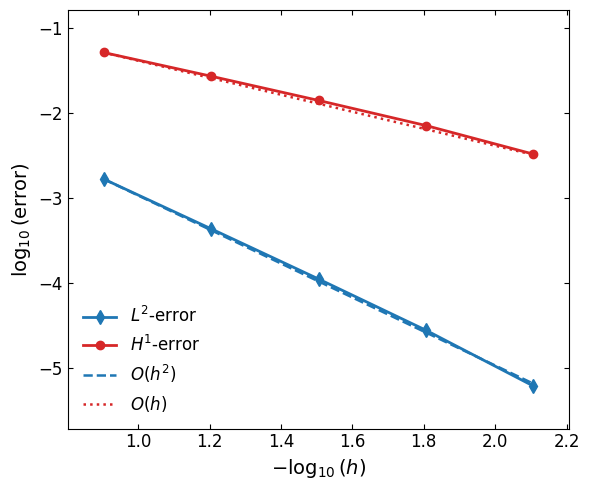

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Data
h = np.array(h_list[:], dtype=float)
L2_err = np.array(rL2s_fem_list[:], dtype=float)
H1_err = np.array(rH1s_list[:], dtype=float)

# Transform axes
x = -np.log10(h)
y_L2 = np.log10(L2_err)
y_H1 = np.log10(H1_err)

fig, ax = plt.subplots(figsize=(6, 5))

# --- Main curves with color ---
ax.plot(
    x, y_L2, "-d",
    color="tab:blue",
    label=r"$L^2$-error",
    lw=2,
    ms=7,
)

ax.plot(
    x, y_H1, "-o",
    color="tab:red",
    label=r"$H^1$-error",
    lw=2,
    ms=6,
)

# --- Reference lines ---
# O(h): slope = -1
k_ref = 2.0
# idx = -3
# x0 = x[idx]
# y0 = y_L2[idx]
# ax.plot(
#     x[idx-1:], y0 - k_ref * (x[idx-1:] - x0),
#     "--",
#     lw=1.8,
#     color="tab:blue",
#     label=r"$O(h)$"
# )

x0 = x[0]
y0 = y_L2[0]
ax.plot(
    x, y0 - k_ref * (x - x0),
    "--",
    lw=1.8,
    color="tab:blue",
    label=r"$O(h^2)$"
)

# O(h^{1/2}): slope = -1/2
k_ref = 1.0
x0 = x[0]
y0 = y_H1[0]
ax.plot(
    x, y0 - k_ref * (x - x0),
    ":",
    lw=1.8,
    color="tab:red",
    label=r"$O(h)$"
)
# x0 = x[-2]
# y0 = y_H1[-2]
# ax.plot(
#     x[-4:], y0 - k_ref * (x[-4:] - x0),
#     ":",
#     lw=1.8,
#     color="tab:red"
# )

# --- Labels & limits ---
ax.set_xlabel(r"$-\log_{10}(h)$", fontsize=14)
ax.set_ylabel(r"$\log_{10}(\text{error})$", fontsize=14)

ax.set_xlim(x.min() - 0.1, x.max() + 0.1)
ax.set_ylim(min(y_L2.min(), y_H1.min()) - 0.5,
            max(y_L2.max(), y_H1.max()) + 0.5)

# No grid
ax.grid(False)

# Ticks
ax.tick_params(direction="in", top=True, right=True, labelsize=12)

# Legend without frame
leg = ax.legend(frameon=False, fontsize=12, loc="best")

plt.tight_layout()
plt.show()


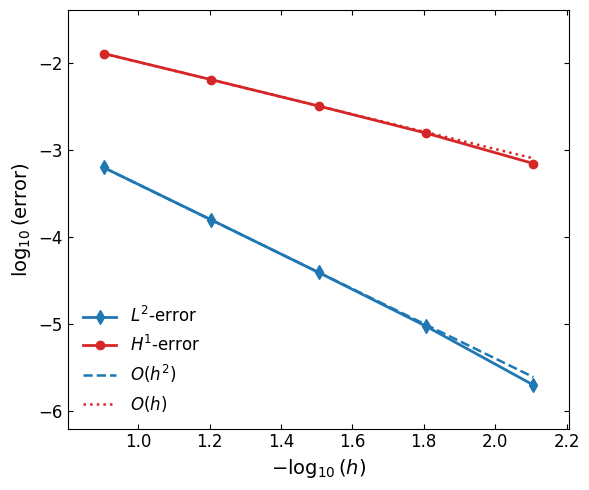

In [59]:
#p_f
import numpy as np
import matplotlib.pyplot as plt

h = np.array(h_list[:], dtype=float)
L2_err = np.array(L2_fem_list_pf[:], dtype=float)
H1_err = np.array(H1s_list_pf[:], dtype=float)

# Transform axes
x = -np.log10(h)
y_L2 = np.log10(L2_err)
y_H1 = np.log10(H1_err)

fig, ax = plt.subplots(figsize=(6, 5))

# --- Main curves with color ---
ax.plot(
    x, y_L2, "-d",
    color="tab:blue",
    label=r"$L^2$-error",
    lw=2,
    ms=7,
)

ax.plot(
    x, y_H1, "-o",
    color="tab:red",
    label=r"$H^1$-error",
    lw=2,
    ms=6,
)

# --- Reference lines ---
# O(h): slope = -1
k_ref = 2
idx = 0
x0 = x[idx]
y0 = y_L2[idx]
ax.plot(
    x[idx:], y0 - k_ref * (x[idx:] - x0),
    "--",
    lw=1.8,
    color="tab:blue",
    label=r"$O(h^2)$"
)

# O(h^{1/2}): slope = -1/2
k_ref = 1.0
x0 = x[0]
y0 = y_H1[0]
ax.plot(
    x, y0 - k_ref * (x - x0),
    ":",
    lw=1.8,
    color="tab:red",
    label=r"$O(h)$"
)

# --- Labels & limits ---
ax.set_xlabel(r"$-\log_{10}(h)$", fontsize=14)
ax.set_ylabel(r"$\log_{10}(\text{error})$", fontsize=14)

ax.set_xlim(x.min() - 0.1, x.max() + 0.1)
ax.set_ylim(min(y_L2.min(), y_H1.min()) - 0.5,
            max(y_L2.max(), y_H1.max()) + 0.5)

# No grid
ax.grid(False)

# Ticks
ax.tick_params(direction="in", top=True, right=True, labelsize=12)

# Legend without frame
leg = ax.legend(frameon=False, fontsize=12, loc="best")

plt.tight_layout()
plt.show()



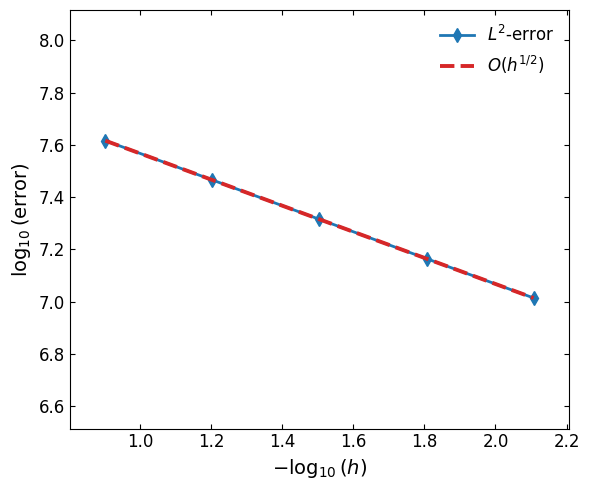

In [61]:
#lmbd
import numpy as np
import matplotlib.pyplot as plt

# Data
h = np.array(h_list[:], dtype=float)
L2_err = np.array(L2_fem_list_lmbd[:], dtype=float)*np.sqrt(h)
# H1_err = np.array(rH1s_list_pf[-N_ref:], dtype=float)

# Transform axes
x = -np.log10(h)
y_L2 = np.log10(L2_err)
# y_H1 = np.log10(H1_err)

fig, ax = plt.subplots(figsize=(6, 5))

# --- Main curves with color ---
ax.plot(
    x, y_L2, "-d",
    color="tab:blue",
    label=r"$L^2$-error",
    lw=2,
    ms=7,
)

# ax.plot(
#     x, y_H1, "-o",
#     color="tab:red",
#     label=r"$H^1$-error",
#     lw=2,
#     ms=6,
# )

# --- Reference lines ---
# O(h): slope = -1
k_ref = 0.5
x0 = x[1]
y0 = y_L2[1]
ax.plot(
    x, y0 - k_ref * (x - x0),
    "--",
    lw=2.8,
    color="tab:red",
    label=r"$O(h^{1/2})$"
)

# --- Labels & limits ---
ax.set_xlabel(r"$-\log_{10}(h)$", fontsize=14)
ax.set_ylabel(r"$\log_{10}(\text{error})$", fontsize=14)

ax.set_xlim(x.min() - 0.1, x.max() + 0.1)
ax.set_ylim(y_L2.min() - 0.5,
            y_L2.max() + 0.5)


# No grid
ax.grid(False)

# Ticks
ax.tick_params(direction="in", top=True, right=True, labelsize=12)

# Legend without frame
leg = ax.legend(frameon=False, fontsize=12, loc="best")

plt.tight_layout()
plt.show()


In [37]:
y_L2

array([7.61645485, 7.46567685, 7.31523663, 7.1647054 , 7.01419275])

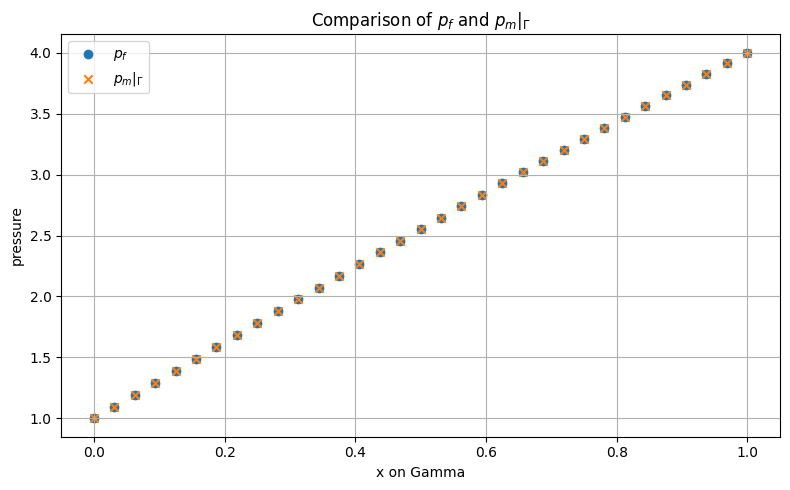

max |p_f - p_m|_Gamma| at fracture DOF points = 7.549516567451064e-15
mean |p_f - p_m|_Gamma| at fracture DOF points = 7.266914343001025e-16


In [2]:
from dolfinx import geometry
import matplotlib.pyplot as plt
# ------------------------------------------------------------
# 1. Coordinates of DOFs on the fracture space V_f
# ------------------------------------------------------------
gamma_dof_coords = V_f.tabulate_dof_coordinates()
# gamma_dof_coords = gamma_dof_coords.reshape((-1, msh.geometry.dim))

# ------------------------------------------------------------
# 2. Build search tree on omega to evaluate p_m at gamma points
# ------------------------------------------------------------
tdim = omega.topology.dim
bb_tree = geometry.bb_tree(omega, tdim)

cell_candidates = geometry.compute_collisions_points(bb_tree, gamma_dof_coords)
colliding_cells = geometry.compute_colliding_cells(omega, cell_candidates, gamma_dof_coords)

# For each gamma point, choose one containing cell in omega
cells = np.full(len(gamma_dof_coords), -1, dtype=np.int32)
valid = np.zeros(len(gamma_dof_coords), dtype=bool)

for i in range(len(gamma_dof_coords)):
    links = colliding_cells.links(i)
    if len(links) > 0:
        cells[i] = links[0]
        valid[i] = True

if not np.all(valid):
    print(f"Warning: {np.count_nonzero(~valid)} gamma DOF points were not found inside omega cells.")

# Keep only valid points
pts = gamma_dof_coords[valid]
cells_valid = cells[valid]

# ------------------------------------------------------------
# 3. Evaluate p_m at the fracture DOF coordinates
# ------------------------------------------------------------
pm_eval = p_m.eval(pts, cells_valid)

# p_m.eval may return shape (N, 1) or (N,)
pm_on_gamma = np.asarray(pm_eval).reshape(-1)

# ------------------------------------------------------------
# 4. Extract p_f values at the same fracture DOFs
# ------------------------------------------------------------
pf_vals = p_f.x.array[:len(gamma_dof_coords)]
pf_vals = pf_vals[valid]

# ------------------------------------------------------------
# 5. Choose a coordinate for plotting
#    If fracture is mostly horizontal -> use x
#    If mostly vertical   -> use y
# ------------------------------------------------------------
x_span = pts[:, 0].max() - pts[:, 0].min()
y_span = pts[:, 1].max() - pts[:, 1].min()

if x_span >= y_span:
    s = pts[:, 0]
    xlabel = "x on Gamma"
else:
    s = pts[:, 1]
    xlabel = "y on Gamma"

# Sort for nicer visualization
perm = np.argsort(s)
s_sorted = s[perm]
pf_sorted = pf_vals[perm]
pm_sorted = pm_on_gamma[perm]

# ------------------------------------------------------------
# 6. Scatter plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(s_sorted, pf_sorted, label=r"$p_f$", marker="o")
plt.scatter(s_sorted, pm_sorted, label=r"$p_m|_{\Gamma}$", marker="x")
plt.xlabel(xlabel)
plt.ylabel("pressure")
plt.title(r"Comparison of $p_f$ and $p_m|_{\Gamma}$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7. Optional: print max mismatch at the DOF points
# ------------------------------------------------------------
err = np.abs(pf_vals - pm_on_gamma)
print("max |p_f - p_m|_Gamma| at fracture DOF points =", err.max())
print("mean |p_f - p_m|_Gamma| at fracture DOF points =", err.mean())

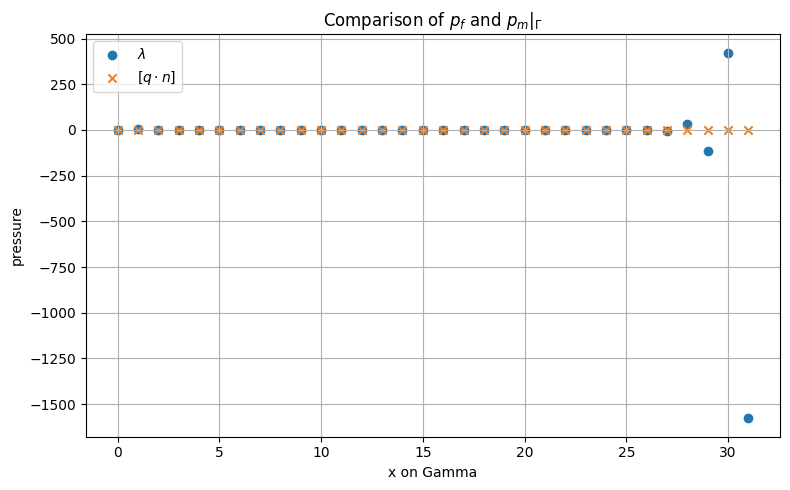

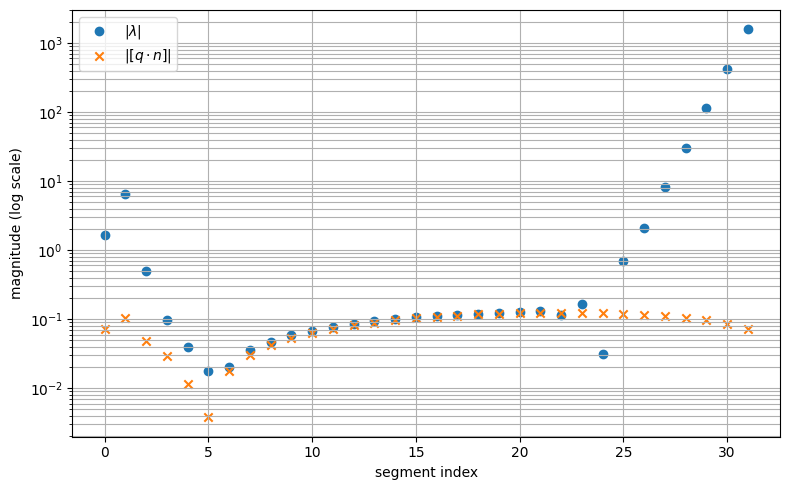

In [3]:
from petsc4py import PETSc
# ------------------------------------------------------------------
# 1. One dof per fracture segment
# ------------------------------------------------------------------
Q0 = fem.functionspace(gamma, ("DG", 0))
w0 = ufl.TestFunction(Q0)

dx_f = ufl.Measure("dx", domain=gamma)

# IMPORTANT:
# fracture inside omega must use dS, not ds
dS_gamma = ufl.Measure("dS", domain=omega, subdomain_data=facet_markers)
# then use dS_gamma(Gamma_tag)

# ------------------------------------------------------------------
# 2. Flux jump in omega
# ------------------------------------------------------------------
n_omega = ufl.FacetNormal(omega)
q = -k_m * ufl.grad(p_m)

# [[q.n]] = q^+·n^+ + q^-·n^-
jump_qn = ufl.jump(q, n_omega)

# ------------------------------------------------------------------
# 3. Segmentwise integral of lambda on gamma
#    vector entry j = integral over gamma-cell g_j of lambda
# ------------------------------------------------------------------
form_lambda = fem.form(lmbd * w0 * dx_f)

b_lambda = petsc.assemble_vector(form_lambda)
# b_lambda.ghostUpdate(addv=PETSc.InsertMode.ADD,
#                      mode=PETSc.ScatterMode.REVERSE)

# ------------------------------------------------------------------
# 4. Segmentwise integral of [[q.n]] on omega facets,
#    but tested with DG0(gamma), so use entity_maps
# ------------------------------------------------------------------
form_jump = fem.form(
    w0("+") * jump_qn * dS_gamma(Gamma_tag),
    entity_maps=[gamma_to_omega]
)

b_jump = petsc.assemble_vector(form_jump)
# b_jump.ghostUpdate(addv=PETSc.InsertMode.ADD,
#                    mode=PETSc.ScatterMode.REVERSE)

# ------------------------------------------------------------------
# 5. Residual per fracture segment:
#    r_g = integral_g lambda - integral_g [[q.n]]
# ------------------------------------------------------------------
b_res = b_lambda.copy()
b_res.axpy(-1.0, b_jump)   # b_res = b_lambda - b_jump

# local owned entries
nloc = Q0.dofmap.index_map.size_local
segment_residuals = b_res.array[:nloc].copy()

# ------------------------------------------------------------
# 6. Scatter plot
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(np.arange(0,len(b_lambda.array)),b_lambda.array, label=r"$\lambda$", marker="o")
plt.scatter(np.arange(0,len(b_lambda.array)), b_jump.array, label=r"$[q \cdot n]$", marker="x")
plt.xlabel(xlabel)
plt.ylabel("pressure")
plt.title(r"Comparison of $p_f$ and $p_m|_{\Gamma}$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Scatter plot (log scale)
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))

x_vals = np.arange(len(b_lambda.array))

# If values can be negative, use absolute value (recommended)
plt.scatter(x_vals, np.abs(b_lambda.array), label=r"$|\lambda|$", marker="o")
plt.scatter(x_vals, np.abs(b_jump.array), label=r"$|[q \cdot n]|$", marker="x")

plt.yscale("log")   # <-- log scale

plt.xlabel("segment index")
plt.ylabel("magnitude (log scale)")
# plt.title(r"Comparison of $\lambda$ and $[q \cdot n]$")
plt.legend()
plt.grid(True, which="both")  # better grid for log scale
plt.tight_layout()
plt.show()

In [4]:
# Number of local + ghost vertices on gamma
imap_g = gamma.topology.index_map(0)
num_gamma_vertices = imap_g.size_local + imap_g.num_ghosts

gamma_vertices = np.arange(num_gamma_vertices, dtype=np.int32)

# Map gamma-submesh vertices to omega-mesh vertices
gamma_to_omega_vertices = gamma_vertex_to_omega.sub_topology_to_topology(
    gamma_vertices, inverse=False
)

In [5]:
from dolfinx.io import XDMFFile
import pathlib

outdir = pathlib.Path("result_conforming_regular")
outdir.mkdir(parents=True, exist_ok=True)

from dolfinx.io import XDMFFile

# ------------------------------
# 1) Save bulk field p_m on Ω
# ------------------------------
omega_file = outdir / "omega_finest.xdmf"
with XDMFFile(omega.comm, str(omega_file), "w") as xdmf:
    xdmf.write_mesh(omega)
    xdmf.write_function(p_m_exact)

# ------------------------------
# 2) Save interface fields p_f, λ on Γ
# ------------------------------
gamma_file = outdir / "gamma_finest.xdmf"
with XDMFFile(gamma.comm, str(gamma_file), "w") as xdmf:
    xdmf.write_mesh(gamma)
    xdmf.write_function(p_f_exact)
    xdmf.write_function(lmbd_exact)

In [6]:
# Access mesh geometry
tdim = omega.topology.dim

# Gather coordinates and connectivity
omega_geometry = omega.geometry.x[:,0:2]  # global array of vertex coords
# Build cell->vertex mapping (fast access)
# Using dolfinx.Cell to get connectivity is more robust, but below uses mesh.topology
cells = omega.topology.connectivity(0, tdim)  # vertices -> cells
# Instead get cell->vertex mapping via mesh.topology.index_map?
# Simpler: use mesh.geometry.x with mesh.topology.connectivity(tdim, 0)
ctv = omega.topology.connectivity(tdim, 0)
if ctv is None:
    omega.topology.create_connectivity(tdim, 0)
    ctv = omega.topology.connectivity(tdim, 0)
# ctv.array() gives flattened vertex indices -> need per-cell view
# There's a helper to get cell entity indices
num_cells = omega.topology.index_map(tdim).size_local  # per-rank local count
# We'll iterate over local cells only
local_cells = np.arange(num_cells, dtype=np.int32)

# For evaluating u_h and kappa, we can use u_h.x.array if needed.
# But easier: create a point evaluation lambda to get value at a point
from dolfinx.fem import Function
u_func = p_m
local_fluxes = {}
Vm_dofmap = V_m.dofmap.index_map.local_range  # not directly used; we'll query dofs per cell

# Get dof indices per cell
# Using dolfinx.fem.locate_dofs_topological is one option, but below we get cell_dofs
dofmap = V_m.dofmap
# But to avoid uncertain reshape semantics, use mesh.topology.connectivity(tdim, 0).entities
# Simpler robust approach: use dolfinx.mesh.cells() to get local cells vertex indices
try:
    from dolfinx.mesh import cells as dolfinx_cells
    local_cell_vertices = dolfinx_cells(mesh)
except Exception:
    # fallback: create by slicing connectivity
    # arr = ctv.array
    # local_cell_vertices = arr.reshape((-1, 3))
    local_cell_vertices = np.array([ctv.links(c) for c in range(ctv.num_nodes)])

tdim = omega.topology.dim
omega.topology.create_connectivity(tdim, tdim - 1)
omega.topology.create_connectivity(tdim - 1, tdim)

c2f = omega.topology.connectivity(tdim, tdim - 1)
f2c = omega.topology.connectivity(tdim - 1, tdim)

num_cells = omega.topology.index_map(tdim).size_local

local_cell_adjacent = [[] for _ in range(num_cells)]

for c in range(num_cells):
    neighbors = set()
    for ff in c2f.links(c):
        for cc in f2c.links(ff):
            if cc != c:
                neighbors.add(int(cc))
    local_cell_adjacent[c] = list(neighbors)

#facet vertices
tdim = omega.topology.dim
fdim = tdim - 1

# Make sure facet -> vertex connectivity exists
if omega.topology.connectivity(fdim, 0) is None:
    omega.topology.create_connectivity(fdim, 0)

f2v = omega.topology.connectivity(fdim, 0)

num_facets = omega.topology.index_map(fdim).size_local
local_facets = np.arange(num_facets, dtype=np.int32)

facet_vertices = []
facet_coords = []

x = omega.geometry.x  # global vertex coordinates

for ff in local_facets:
    verts = f2v.links(ff)          # vertex indices of facet f
    coords = x[verts]             # coordinates of those vertices

    facet_vertices.append(verts)
    facet_coords.append(coords)



In [7]:

import numpy as np
from collections import defaultdict

def compute_cell_subdomains_from_connectivity(
    local_cell_vertices,
    omega_geometry,
    n_per_dim,
    x0=0.0, x1=1.0,
    y0=0.0, y1=1.0,
):
    """
    Connectivity-based subdomain adjacency detection.
    Works for structured triangular meshes.

    Returns:
        cell_subdomain : list of lists
            [own_subdomain, adj1, adj2, ...]
    """

    m = n_per_dim
    dx = (x1 - x0) / m
    dy = (y1 - y0) / m

    n_cells = len(local_cell_vertices)

    # -------------------------------------------------
    # 1. Compute centroid-based OWNERSHIP only
    # -------------------------------------------------
    centroids = np.array([
        omega_geometry[verts].mean(axis=0)
        for verts in local_cell_vertices
    ])

    own_sub = []

    for x_c, y_c in centroids:
        ix = int((x_c - x0) / dx)
        iy = int((y_c - y0) / dy)

        ix = max(0, min(m - 1, ix))
        iy = max(0, min(m - 1, iy))

        own_sub.append(iy * m + ix)

    # -------------------------------------------------
    # 2. Build edge-to-cell map
    # -------------------------------------------------
    edge_map = defaultdict(list)

    for cell_id, verts in enumerate(local_cell_vertices):
        nv = len(verts)
        for k in range(nv):
            v0 = verts[k]
            v1 = verts[(k + 1) % nv]

            edge = tuple(sorted((v0, v1)))
            edge_map[edge].append(cell_id)

    # -------------------------------------------------
    # 3. Detect adjacency via shared edges
    # -------------------------------------------------
    cell_subdomain = []

    for cell_id in range(n_cells):

        subs = [own_sub[cell_id]]

        verts = local_cell_vertices[cell_id]
        nv = len(verts)

        for k in range(nv):
            v0 = verts[k]
            v1 = verts[(k + 1) % nv]
            edge = tuple(sorted((v0, v1)))

            neighbors = edge_map[edge]

            for nb in neighbors:
                if nb == cell_id:
                    continue

                nb_sub = own_sub[nb]
                if nb_sub != own_sub[cell_id] and nb_sub not in subs:
                    subs.append(nb_sub)

        cell_subdomain.append(subs)

    return cell_subdomain


num_subdomains = 1
cell_subdomain = compute_cell_subdomains_from_connectivity(local_cell_vertices, omega_geometry, int(np.sqrt(num_subdomains)))

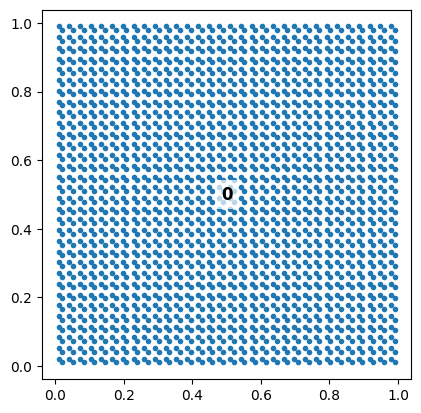

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

centroids = np.array([omega_geometry[i].mean(axis=0) 
                      for i in local_cell_vertices])
# Extract subdomain IDs
sub_ids = np.array([cell_subdomain[idx][0] for idx in range(len(centroids))])
centroids_arr = np.array(centroids)

# Unique subdomains
unique_subdomains = np.unique(sub_ids)

# Colormap
cmap = plt.get_cmap("tab10")
color_map = {sd: cmap(i % 10) for i, sd in enumerate(unique_subdomains)}

# Plot points per subdomain
for sd in unique_subdomains:
    mask = sub_ids == sd
    pts = centroids_arr[mask]

    ax.plot(pts[:, 0], pts[:, 1], '.',
            color=color_map[sd],
            label=f"Subdomain {sd}")

    # Compute average location for single annotation
    mean_x = np.mean(pts[:, 0])
    mean_y = np.mean(pts[:, 1])

    ax.text(mean_x, mean_y,
            f"{sd}",
            fontsize=12,
            fontweight='bold',
            ha='center', va='center',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax.set_aspect('equal')
# ax.legend()
plt.show()

In [9]:
import basix
from dolfinx import mesh as dmesh
from tqdm import tqdm

def precompute_cell_flux_and_source():
    """
    Precompute, for each cell K:
        int_qcg[K] = ∫_{∂K} q_CG · n ds
        int_f[K]   = ∫_K f dx
    where q_CG = -k_m * grad(p_sol).

    Returns:
        cell_flux: dict mapping cell_idx -> (int_qcg, int_f)
    """
    cell_flux = {}

    gdim = omega_geometry.shape[1]

    # 1-cell template mesh
    coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))
    loc_cells = np.array([[0, 1, 2]], dtype=np.int64)
    dummy_coords = np.zeros((3, gdim), dtype=omega_geometry.dtype)

    local_mesh = dmesh.create_mesh(MPI.COMM_SELF, loc_cells, coord_el, dummy_coords)

    tdim = local_mesh.topology.dim

    V_loc = fem.functionspace(local_mesh, ("CG", order + 1, (gdim,)))
    P_loc = fem.functionspace(local_mesh, ("CG", order))

    p_K = fem.Function(P_loc)
    k_m_loc = fem.Function(P_loc)
    f_m_loc = fem.Function(P_loc)

    # Local DOFs for the single template cell
    local_dofs = P_loc.dofmap.cell_dofs(0)

    n_K = ufl.FacetNormal(local_mesh)
    q_CG = -k_m_loc * ufl.grad(p_K)

    ds = ufl.ds(domain=local_mesh)
    dx = ufl.dx(domain=local_mesh)

    for cell_idx, cell_verts in enumerate(tqdm(local_cell_vertices)):
        coords = omega_geometry[cell_verts]
        # update geometry
        local_mesh.geometry.x[:, :gdim] = coords

        # copy global DOFs into local functions
        global_dofs = V_m.dofmap.cell_dofs(cell_idx)
        p_K.x.array[local_dofs] = p_m.x.array[global_dofs]
        k_m_loc.x.array[local_dofs] = k_m.x.array[global_dofs]
        f_m_loc.x.array[local_dofs] = f_m.x.array[global_dofs]

        p_K.x.scatter_forward()
        k_m_loc.x.scatter_forward()
        f_m_loc.x.scatter_forward()

        # assemble cell-level quantities
        int_qcg = fem.assemble_scalar(fem.form(ufl.dot(q_CG, n_K) * ds))
        int_f   = fem.assemble_scalar(fem.form(f_m_loc * dx))

        cell_flux[cell_idx] = (float(int_qcg), float(int_f))

    return cell_flux

cell_flux = precompute_cell_flux_and_source()

100%|██████████| 2048/2048 [00:08<00:00, 236.28it/s]


In [10]:
def precompute_interface_cg_fluxes():
    """
    Precompute ∫_e q_CG · n_K ds for every cell edge.
    Returns:
        cg_flux[(cell_idx, local_edge_id)] = float
    """

    cg_flux = {}

    gdim = omega_geometry.shape[1]

    coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))
    loc_cells = np.array([[0, 1, 2]], dtype=np.int64)
    dummy_coords = np.zeros((3, gdim), dtype=omega_geometry.dtype)

    local_mesh = dmesh.create_mesh(MPI.COMM_SELF, loc_cells, coord_el, dummy_coords)

    tdim = local_mesh.topology.dim
    fdim = tdim - 1

    local_mesh.topology.create_connectivity(tdim, fdim)
    local_mesh.topology.create_connectivity(fdim, tdim)
    local_mesh.topology.create_connectivity(0, fdim)
    local_mesh.topology.create_connectivity(fdim, 0)

    num_facets = local_mesh.topology.index_map(fdim).size_local

    facets = np.arange(num_facets, dtype=np.int32)
    facet_values = np.arange(num_facets, dtype=np.int32)
    facet_tags = mesh.meshtags(local_mesh, fdim, facets, facet_values)

    ds = ufl.Measure("ds", domain=local_mesh, subdomain_data=facet_tags)

    V_loc = fem.functionspace(local_mesh, ("CG", order + 1, (gdim,)))
    P_loc = fem.functionspace(local_mesh, ("CG", order))

    p_K = fem.Function(P_loc)
    k_m_loc = fem.Function(P_loc)

    local_dofs = P_loc.dofmap.cell_dofs(0)

    n_K = ufl.FacetNormal(local_mesh)
    q_CG = -k_m_loc * ufl.grad(p_K)

    # Build edge mapping
    v_to_f = local_mesh.topology.connectivity(0, fdim)
    f_to_v = local_mesh.topology.connectivity(fdim, 0)

    edge_to_facet = {}
    for v0 in range(3):
        for fct in v_to_f.links(v0):
            verts = f_to_v.links(fct)
            for v1 in verts:
                if v1 != v0:
                    edge_to_facet[(v0, v1)] = fct

    edge_indices_loc = [(0, 1), (1, 2), (2, 0)]

    for cell_idx, cell_verts in enumerate(tqdm(local_cell_vertices)):

        coords = omega_geometry[cell_verts]
        local_mesh.geometry.x[:, :gdim] = coords

        global_dofs = V_m.dofmap.cell_dofs(cell_idx)

        p_K.x.array[local_dofs] = p_m.x.array[global_dofs]
        k_m_loc.x.array[local_dofs] = k_m.x.array[global_dofs]

        p_K.x.scatter_forward()
        k_m_loc.x.scatter_forward()

        for edge_loc, (v0, v1) in enumerate(edge_indices_loc):
            facet_id = edge_to_facet[(v0, v1)]

            value = fem.assemble_scalar(
                fem.form(ufl.dot(q_CG, n_K) * ds(facet_id))
            )

            cg_flux[(cell_idx, edge_loc)] = value

    return cg_flux

cg_flux = precompute_interface_cg_fluxes()

100%|██████████| 2048/2048 [00:14<00:00, 140.81it/s]


In [11]:
import torch
num_vertices = omega_geometry.shape[0]

# 1) Build vertex → {subdomains} map  (unchanged)
vertex_subdomains = [set() for _ in range(num_vertices)]
for local_cell_idx, cell_verts in enumerate(local_cell_vertices):
    sd = cell_subdomain[local_cell_idx][0]  # 0,1,2,3
    for v in cell_verts:
        vertex_subdomains[v].add(sd)
vertex_subdomains = [sorted(vv) for vv in vertex_subdomains]


# --- connectivity on the global mesh (used for neighbor search) ---
tdim = omega.topology.dim
omega.topology.create_connectivity(0, tdim)
cells_vtx = omega.topology.connectivity(0, tdim)

# randomize cell order (unchanged logic)
# pairs = list(enumerate(local_cell_vertices))
# random.shuffle(pairs)

# ------------------------------------------------------------
# NEW: Precompute a single 1-cell local mesh + spaces + facet tags
# ------------------------------------------------------------
gdim = omega_geometry.shape[1]

coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))
loc_cells = np.array([[0, 1, 2]], dtype=np.int64)
dummy_coords = np.zeros((3, gdim), dtype=omega_geometry.dtype)

local_mesh = dmesh.create_mesh(MPI.COMM_SELF, loc_cells, coord_el, dummy_coords)
tdim_loc = local_mesh.topology.dim
fdim = tdim_loc - 1

local_mesh.topology.create_connectivity(tdim_loc, fdim)
local_mesh.topology.create_connectivity(fdim, tdim_loc)
local_mesh.topology.create_connectivity(0, fdim)
local_mesh.topology.create_connectivity(fdim, 0)

num_facets = local_mesh.topology.index_map(fdim).size_local

# Tag each facet with its own index: 0,1,2
facets = np.arange(num_facets, dtype=np.int32)
facet_values = np.arange(num_facets, dtype=np.int32)
facet_tags = mesh.meshtags(local_mesh, fdim, facets, facet_values)

ds = ufl.Measure("ds", domain=local_mesh, subdomain_data=facet_tags)

V_loc = fem.functionspace(local_mesh, ("CG", order + 1, (gdim,)))
P_loc = fem.functionspace(local_mesh, ("CG", order))

p_K = fem.Function(P_loc)
k_m_loc = fem.Function(P_loc)
f_m_loc = fem.Function(P_loc)

# Local DOFs for the single cell of the template mesh
local_dofs = P_loc.dofmap.cell_dofs(0)

n_K = ufl.FacetNormal(local_mesh)
q_CG = -k_m_loc * ufl.grad(p_K)

# Build a robust edge (v0,v1) -> facet_id map once
v_to_f = local_mesh.topology.connectivity(0, fdim)
f_to_v = local_mesh.topology.connectivity(fdim, 0)
edge_to_facet = {}
for v0 in range(3):
    for fct in v_to_f.links(v0):
        verts = f_to_v.links(fct)
        for v1 in verts:
            if v1 != v0:
                edge_to_facet[(v0, v1)] = fct

# Local edge list (same as before)
edge_indices_loc = [(0, 1), (1, 2), (2, 0)]

# Precompute geometry tensor (no grad; acts as constant input to nets)
omega_geometry_t = torch.tensor(omega_geometry, dtype=torch.float32)
edge_pair_to_id = {
    (0, 1): 0,
    (1, 2): 1,
    (2, 0): 2,
    (1, 0): 0,
    (2, 1): 1,
    (0, 2): 2,
}

In [12]:
import math
def build_interface_edges():
    """
    Identify all interface edges and store their geometric + CG data.
    No neural network calls.
    No integration.
    """

    sd_left_list = []
    sd_right_list = []

    x0_list = []
    x1_list = []

    normal_left_list = []
    length_list = []

    qcg_left_list = []
    qcg_right_list = []

    for local_cell_idx, cell_verts in enumerate(local_cell_vertices):

        sd = cell_subdomain[local_cell_idx][0]
        cell_verts_np = np.asarray(cell_verts, dtype=np.int64)

        coords = omega_geometry[cell_verts_np]
        centroid = coords.mean(axis=0)
        centroid_t = torch.tensor(centroid, dtype=torch.float32)

        for edge_loc, (v0_loc, v1_loc) in enumerate(edge_indices_loc):

            i0 = int(cell_verts_np[v0_loc])
            i1 = int(cell_verts_np[v1_loc])

            # --- Must be interface edge ---
            if (len(vertex_subdomains[i0]) < 2 or
                len(vertex_subdomains[i1]) < 2):
                continue

            edge_sds = set(vertex_subdomains[i0]) & set(vertex_subdomains[i1])
            sd_adj_set = edge_sds - {sd}

            if len(sd_adj_set) != 1:
                continue

            sd_adj = next(iter(sd_adj_set))

            # --- Find neighboring cell sharing this edge ---
            cells0 = cells_vtx.links(i0)
            cells1 = cells_vtx.links(i1)
            common_cells = np.intersect1d(cells0, cells1)

            neighbor_cells = [
                int(c) for c in common_cells
                if int(c) != local_cell_idx
            ]

            if not neighbor_cells:
                continue

            local_cell_idx_adj = neighbor_cells[0]
            cell_verts_adj = local_cell_vertices[local_cell_idx_adj]

            try:
                loc0_adj = int(np.where(cell_verts_adj == i0)[0][0])
                loc1_adj = int(np.where(cell_verts_adj == i1)[0][0])
            except IndexError:
                continue

            edge_loc_adj = edge_pair_to_id[(loc0_adj, loc1_adj)]

            # --- CG flux (precomputed floats) ---
            qcg_left = cg_flux.get((local_cell_idx, edge_loc), 0.0)
            qcg_right = cg_flux.get((local_cell_idx_adj, edge_loc_adj), 0.0)

            # --- Geometry ---
            x0 = omega_geometry_t[i0]
            x1 = omega_geometry_t[i1]

            t = x1 - x0
            L = torch.linalg.norm(t)
            if L <= 0:
                continue

            # outward normal w.r.t current cell
            n_edge = torch.stack([t[1], -t[0]]) / L
            midpoint = 0.5 * (x0 + x1)

            if torch.dot(n_edge, centroid_t - midpoint) > 0:
                n_edge = -n_edge

            # --- Store ---
            sd_left_list.append(sd)
            sd_right_list.append(sd_adj)

            x0_list.append(x0)
            x1_list.append(x1)

            normal_left_list.append(n_edge)
            length_list.append(L)

            qcg_left_list.append(qcg_left)
            qcg_right_list.append(qcg_right)

    # --- Convert to tensors ---

    interface_data = {
        "sd_left": torch.tensor(sd_left_list, dtype=torch.long),
        "sd_right": torch.tensor(sd_right_list, dtype=torch.long),

        "x0": torch.stack(x0_list),
        "x1": torch.stack(x1_list),

        "normal_left": torch.stack(normal_left_list),
        "length": torch.stack(length_list),

        "qcg_left": torch.tensor(qcg_left_list, dtype=torch.float32),
        "qcg_right": torch.tensor(qcg_right_list, dtype=torch.float32),
    }

    return interface_data

if num_subdomains > 1:
    interface_data = build_interface_edges()
xi = torch.tensor(
        [
            0.5 * (1.0 - 1.0 / math.sqrt(3.0)),
            0.5 * (1.0 + 1.0 / math.sqrt(3.0)),
        ],
        dtype=torch.float32
    )
wi = torch.tensor([0.5, 0.5], dtype=torch.float32)
def integrate_edge_flux_batch(net, x0, x1, n_edge, L, xi, wi, num_sub):
    """
    Compute ∫_edge (net(x) · n_edge) ds
    for MANY edges at once using composite quadrature.

    Parameters
    ----------
    net : neural network
    x0, x1 : (Ne, dim)
    n_edge : (Ne, dim)
    L : (Ne,)
    xi, wi : 1D quadrature rule on [0,1]
    num_sub : number of composite subintervals

    Returns
    -------
    integral : (Ne,)
    """

    device = x0.device
    Ne, dim = x0.shape

    # Edge direction
    t = x1 - x0  # (Ne, dim)

    # Convert quadrature rule to tensors
    xi_t = torch.as_tensor(xi, dtype=x0.dtype, device=device)
    wi_t = torch.as_tensor(wi, dtype=x0.dtype, device=device)

    nq = xi_t.numel()
    h = 1.0 / num_sub

    # ------------------------------------------------------------
    # Build composite quadrature points
    # ------------------------------------------------------------

    # Subinterval offsets
    j = torch.arange(num_sub, device=device).unsqueeze(1)  # (num_sub, 1)
    s_left = j * h                                         # (num_sub, 1)

    # All quadrature locations in [0,1]
    s = s_left + h * xi_t.unsqueeze(0)                     # (num_sub, nq)
    s = s.reshape(-1)                                      # (num_sub*nq,)

    Nq_total = s.numel()

    # Composite weights
    w = (h * wi_t).repeat(num_sub)                         # (num_sub*nq,)

    # ------------------------------------------------------------
    # Build all quadrature points for all edges
    # ------------------------------------------------------------

    # (Ne, Nq_total, dim)
    x_q = x0.unsqueeze(1) + s.view(1, -1, 1) * t.unsqueeze(1)

    # Flatten for NN evaluation
    x_q_flat = x_q.reshape(-1, dim)                        # (Ne*Nq_total, dim)

    # Single batched NN call
    r_q_flat = net(x_q_flat)                               # (Ne*Nq_total, dim)

    # Reshape back
    r_q = r_q_flat.view(Ne, Nq_total, dim)                 # (Ne, Nq_total, dim)

    # ------------------------------------------------------------
    # Compute dot product with normals
    # ------------------------------------------------------------

    # (Ne, Nq_total)
    flux_q = torch.sum(r_q * n_edge.unsqueeze(1), dim=2)

    # ------------------------------------------------------------
    # Integrate
    # ------------------------------------------------------------

    # Broadcast:
    # L.unsqueeze(1) -> (Ne,1)
    # w.view(1,-1)   -> (1,Nq_total)
    weighted = flux_q * (L.unsqueeze(1) * w.view(1, -1))

    integral = torch.sum(weighted, dim=1)                  # (Ne,)

    return integral

def compute_subdomain_continuity_vectorized(nets):
    """
    Fully vectorized subdomain continuity loss.
    No topology traversal.
    Batched NN integration.
    """

    device = interface_data["x0"].device

    sd_left = interface_data["sd_left"]
    sd_right = interface_data["sd_right"]

    x0 = interface_data["x0"]
    x1 = interface_data["x1"]
    normal_left = interface_data["normal_left"]
    length = interface_data["length"]

    qcg_left = interface_data["qcg_left"]
    qcg_right = interface_data["qcg_right"]

    Ne = x0.shape[0]

    # Accumulate per-edge residual contributions
    residual = torch.zeros(Ne, device=device)

    # --- LEFT contributions ---
    for k in range(num_subdomains):

        mask = (sd_left == k)
        if mask.any():

            x0_k = x0[mask]
            x1_k = x1[mask]
            n_k  = normal_left[mask]
            L_k  = length[mask]

            flux_left = integrate_edge_flux_batch(
                nets[k], x0_k, x1_k, n_k, L_k, xi, wi, num_sub=3
            )

            residual[mask] += flux_left + qcg_left[mask]

    # --- RIGHT contributions ---
    for k in range(num_subdomains):

        mask = (sd_right == k)
        if mask.any():

            x0_k = x0[mask]
            x1_k = x1[mask]
            n_k  = -normal_left[mask]   # flip normal
            L_k  = length[mask]

            flux_right = integrate_edge_flux_batch(
                nets[k], x0_k, x1_k, n_k, L_k, xi, wi, num_sub=3
            )

            residual[mask] += flux_right + qcg_right[mask]

    # --- Compute per-subdomain loss ---
    loss_sd = torch.zeros(num_subdomains, device=device)

    for k in range(num_subdomains):

        mask = (sd_left == k)
        if mask.any():
            loss_sd[k] = torch.mean(residual[mask] ** 2)

    return loss_sd

In [13]:
from dolfinx.fem.petsc import LinearProblem

# Bulk extension we want
lmbd_bulk = fem.Function(V_m, name="lmbd_bulk")

bulk_vals = np.zeros_like(lmbd_bulk.x.array)
bulk_vals[gamma_to_omega_vertices] = lmbd.x.array

lmbd_bulk.x.array[:] = bulk_vals
lmbd_bulk.x.scatter_forward()

with XDMFFile(omega.comm, str(outdir / "lmbd_bulk.xdmf"), "w") as xdmf:
    xdmf.write_mesh(omega)
    xdmf.write_function(lmbd_bulk)

In [14]:
from dolfinx.mesh import meshtags
omega.topology.create_connectivity(tdim, fdim)
omega.topology.create_connectivity(fdim, tdim)

cell_to_facet = omega.topology.connectivity(tdim, fdim)
facet_to_cell = omega.topology.connectivity(fdim, tdim)
LCE_CG = []
indices = []

LCE_CG_int = []
indices_int = []
for local_cell_idx, cell_verts in enumerate(tqdm(local_cell_vertices)):
    # cell_verts are global vertex indices
    coords = omega_geometry[cell_verts]  # shape (3,2)
    sd = cell_subdomain[local_cell_idx][0]
    centroid = np.mean(coords, axis=0).reshape(1,-1)

    # loc_cells = np.array([[0, 1, 2]], dtype=np.int32)
    loc_cells = np.array([local_cell_idx], dtype=np.int32)

    gdim = coords.shape[1]
    coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))
    
    local_gamma_facets = []

    for f in gamma_entities:
        cells = facet_to_cell.links(f)
        if any(c in loc_cells for c in cells):
            local_gamma_facets.append(f)

    # local_mesh = dmesh.create_mesh(
    #     MPI.COMM_SELF,
    #     loc_cells,
    #     coord_el,   # <-- this is the required "e" argument
    #     coords
    # )
    fdim = tdim - 1

    local_mesh, cell_map, vertex_map, geom_map = mesh.create_submesh(omega, tdim, loc_cells)

    omega.topology.create_connectivity(tdim, fdim)
    omega.topology.create_connectivity(fdim, 0)
    local_mesh.topology.create_connectivity(fdim, 0)

    gamma_set = set(np.asarray(gamma_entities, dtype=np.int32))

    # single-cell submesh -> local cell 0
    parent_cell = cell_map.sub_topology_to_topology(
        np.array([0], dtype=np.int32), False
    )[0]

    # local_facets = []
    # local_values = []

    # for lf in range(local_mesh.topology.index_map(fdim).size_local):
    #     # vertices of local facet in submesh numbering
    #     lf_vertices_local = local_mesh.topology.connectivity(fdim, 0).links(lf)

    #     # map submesh vertices -> parent mesh vertices
    #     lf_vertices_parent = np.sort(
    #         vertex_map.sub_topology_to_topology(
    #             np.asarray(lf_vertices_local, dtype=np.int32), False
    #         )
    #     )

    #     matched_parent_facet = None
    #     for gf in omega.topology.connectivity(tdim, fdim).links(parent_cell):
    #         gf_vertices = np.sort(
    #             omega.topology.connectivity(fdim, 0).links(gf)
    #         )
    #         if np.array_equal(lf_vertices_parent, gf_vertices):
    #             matched_parent_facet = gf
    #             break

    #     if matched_parent_facet is None:
    #         raise RuntimeError(f"Could not match local facet {lf} to a parent facet")

    #     if matched_parent_facet in gamma_set:
    #         local_facets.append(lf)
    #         local_values.append(Gamma_tag)
    local_facets = []
    local_values = []
    other_tag = 1  # or whatever label you want
    for lf in range(local_mesh.topology.index_map(fdim).size_local):
        lf_vertices_local = local_mesh.topology.connectivity(fdim, 0).links(lf)

        lf_vertices_parent = np.sort(
            vertex_map.sub_topology_to_topology(
                np.asarray(lf_vertices_local, dtype=np.int32), False
            )
        )

        matched_parent_facet = None
        for gf in omega.topology.connectivity(tdim, fdim).links(parent_cell):
            gf_vertices = np.sort(
                omega.topology.connectivity(fdim, 0).links(gf)
            )
            if np.array_equal(lf_vertices_parent, gf_vertices):
                matched_parent_facet = gf
                break

        if matched_parent_facet is None:
            raise RuntimeError(f"Could not match local facet {lf} to a parent facet")

        # ✅ Always append now
        local_facets.append(lf)

        if matched_parent_facet in gamma_set:
            local_values.append(Gamma_tag)
        else:
            local_values.append(other_tag)

    if len(local_facets) > 0:
        local_facet_tags = mesh.meshtags(
            local_mesh,
            fdim,
            np.array(local_facets, dtype=np.int32),
            np.array(local_values, dtype=np.int32),
        )
    # -------------------------------------------------
    # 2. Local vector CG2 space for r_θ
    # -------------------------------------------------
    # Vector-valued CG2 (shape=(gdim,))
    # V_loc = fem.functionspace(local_mesh, ("CG", order))
    # r_loc = fem.Function(V_loc)

    # -------------------------------------------------
    # 3. Interpolate NN into r_loc via dof coordinates
    # -------------------------------------------------
    # x_loc = V_loc.tabulate_dof_coordinates()[:,0:2]  # (Ndofs, gdim)
    
    # -------------------------------------------------
    # 4. Compute ∫_{∂D_j} r_θ · n ds on local mesh
    # -------------------------------------------------
    n_K = ufl.FacetNormal(local_mesh)
    
    # int_r_local = fem.assemble_scalar(int_r_form)

    # -------------------------------------------------
    # 5. Combine with q_cg and f (precomputed per cell)
    # -------------------------------------------------
    P_loc = fem.functionspace(local_mesh, ("CG", order))
    p_K = fem.Function(P_loc)

    # DOFs on this cell in the global space
    global_dofs = V_m.dofmap.cell_dofs(local_cell_idx)

    # DOFs on the (only) cell in the local space
    local_dofs = P_loc.dofmap.cell_dofs(0)

    p_K.x.array[local_dofs] = p_m.x.array[global_dofs]
    p_K.x.scatter_forward()

    k_m_loc = fem.Function(P_loc)
    k_m_loc.x.array[local_dofs] = k_m.x.array[global_dofs]

    q_CG = -k_m_loc * ufl.grad(p_K)
    int_qcg = fem.assemble_scalar(
                fem.form(ufl.dot(q_CG, n_K) * ufl.ds(domain=local_mesh))
            )   # ∫_{∂D_j} q_cg · n
    
    f_m_loc = fem.Function(P_loc)
    f_m_loc.x.array[local_dofs] = f_m.x.array[global_dofs]
    f_m_loc.x.scatter_forward()
    int_f   = fem.assemble_scalar(fem.form(f_m_loc * ufl.dx(domain=local_mesh)))       # ∫_{D_j} f

    lmbd_loc = fem.functionspace(local_mesh, ("CG", order))
    lmbd_K = fem.Function(lmbd_loc)
    lmbd_K.x.array[local_dofs] = lmbd_bulk.x.array[global_dofs]
    lmbd_K.x.scatter_forward()
    ds_loc = ufl.Measure("ds", domain=local_mesh, subdomain_data=local_facet_tags)

    int_lmbd = fem.assemble_scalar(fem.form(lmbd_K * ds_loc(Gamma_tag)))/2
    # if int_lmbd != 0:
    #     print(int_lmbd)
    LCE_CG.append(int_qcg - int_f - int_lmbd)
    indices.append(local_cell_idx)

    left_dofs_P = fem.locate_dofs_geometrical(
        P_loc, lambda x: np.isclose(x[0], xmin, atol=tol)
    )
    right_dofs_P = fem.locate_dofs_geometrical(
        P_loc, lambda x: np.isclose(x[0], xmax, atol=tol)
    )

    if (len(left_dofs_P) == 0) and (len(right_dofs_P) == 0):
        LCE_CG_int.append(int_qcg - int_f - int_lmbd)
        indices_int.append(local_cell_idx)

100%|██████████| 2048/2048 [00:29<00:00, 69.21it/s]


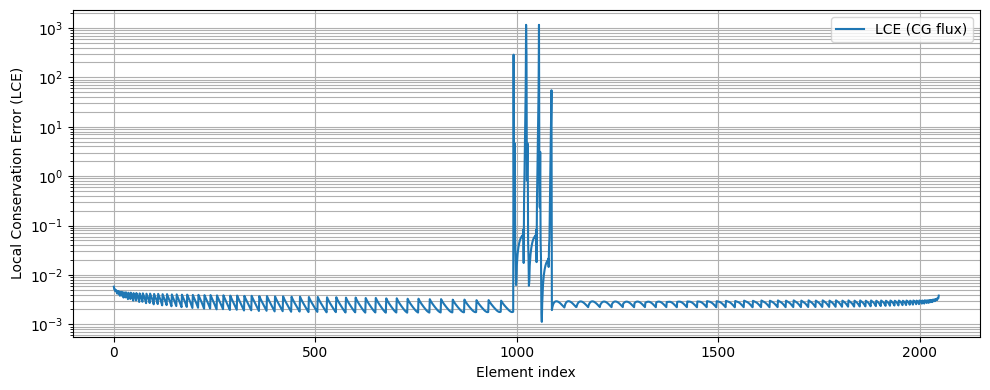

In [38]:
indices_plot = np.array(indices, dtype=int)
LCE_CG_plot = np.array(np.abs(LCE_CG), dtype=float)

plt.figure(figsize=(10,4))
plt.plot(indices_plot, LCE_CG_plot, label="LCE (CG flux)")

plt.yscale("log")  # <-- log scale for y-axis


plt.xlabel("Element index")
plt.ylabel("Local Conservation Error (LCE)")
# plt.title("LCE per element: CG vs Reconstructed flux")
plt.legend()
plt.grid(True, which="both")  # better for log scale
plt.tight_layout()
plt.show()

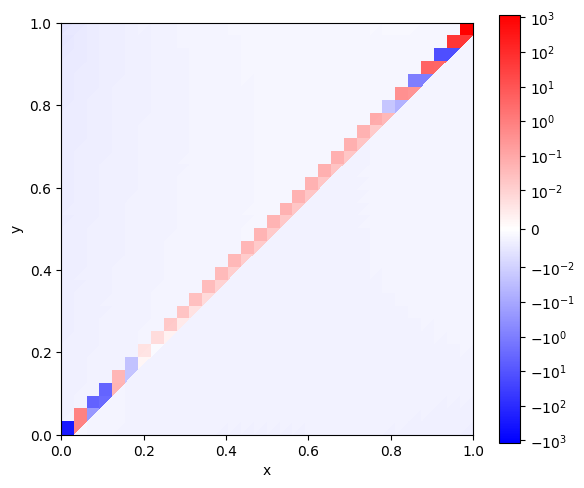

In [39]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np

# --- Mesh data ---
coords = omega.geometry.x
cells = omega.topology.connectivity(omega.topology.dim, 0).array.reshape(-1, 3)

# --- DG0 values (cellwise) ---
values = np.zeros(len(cells))
for cell, val in zip(indices, LCE_CG):
    values[cell] = val

# --- Symmetric color scale ---
vmax = np.max(np.abs(LCE_CG))
# vmax = 1
vmin = -vmax

# --- Build triangulation ---
triang = tri.Triangulation(coords[:, 0], coords[:, 1], cells)

from matplotlib.colors import SymLogNorm

linthresh = 1e-2   # threshold around zero (tune this!)

plt.figure(figsize=(6, 5))
tpc = plt.tripcolor(
    triang,
    facecolors=values,
    cmap="bwr",
    norm=SymLogNorm(
        linthresh=linthresh,
        vmin=-vmax,
        vmax=vmax,
        base=10
    ),
    # edgecolors="k",
)

# plt.plot([0,1],[0,1],'r')

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.colorbar(tpc)
plt.gca().set_aspect("equal")
# plt.title("Local Conservation Error (symlog scale)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [17]:
import numpy as np
import torch
import torch.nn as nn
import cma
from tqdm import tqdm
import basix
from dolfinx import default_scalar_type, mesh as dmesh
import math

# ---------------------------------------------------------
# 1. Define a small NN for flux (or flux correction)
# ---------------------------------------------------------
class AdaptiveTanh(nn.Module):
    def __init__(self, n=5.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(1.0 / n))  # scalar a^k

    def forward(self, x):
        return torch.tanh(self.a * x)
    
class AdaptiveSin(nn.Module):
    def __init__(self, n=5.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(1.0 / n))  # scalar a^k

    def forward(self, x):
        return torch.sin(self.a * x) #+ torch.cos(self.a * x)
    
class PolynomialFeatures(nn.Module):
    def forward(self, x):
        # x : (N, 2)
        x1 = x[:, 0:1]
        x2 = x[:, 1:2]

        return torch.cat([
            x1,
            x2,
            x1**2,
            x2**2,
            x1 * x2
        ], dim=1)
    
class FluxNet(nn.Module):
    def __init__(
        self,
        in_dim=1,
        out_dim=1,
        hidden_dim=32,
        num_hidden_layers=5,
        n=5.0,
    ):
        super().__init__()

        layers = []

        # First layer (input → hidden)
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(AdaptiveTanh(n=n))

        # Hidden layers
        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(AdaptiveTanh(n=n))

        # Output layer
        layers.append(nn.Linear(hidden_dim, out_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x: tensor of shape (N, in_dim)
        return self.net(x)
    
    def slope_recovery_term(self):
        # collect all a^k from hidden layers
        slopes = []
        for m in self.net:
            if isinstance(m, AdaptiveTanh) or isinstance(m, AdaptiveSin):
                slopes.append(m.a)

        a = torch.stack(slopes)                 # shape: (L-1,)
        return 1.0 / torch.mean(torch.exp(a))   # S(a)
    
    def zero_last_layer(self):
        last = self.net[-1]
        nn.init.constant_(last.weight, 0.0)
        if last.bias is not None:
            nn.init.constant_(last.bias, 0.0)

    def siren_init(self):
        """
        Apply SIREN initialization to all Linear layers.
        Assumes AdaptiveSin(n=n) uses frequency multiplier n.
        """
        for i, m in enumerate(self.net):
            if isinstance(m, nn.Linear):
                fan_in = m.in_features

                if i == 0:
                    # First layer
                    bound = 1.0 / fan_in
                else:
                    # Hidden layers
                    # Find preceding AdaptiveSin to get its frequency n
                    prev = self.net[i - 1]
                    if isinstance(prev, AdaptiveSin):
                        omega = float(prev.a)
                    else:
                        omega = 1.0

                    bound = (math.sqrt(6 / fan_in)) / omega

                nn.init.uniform_(m.weight, -bound, bound)

                if m.bias is not None:
                    nn.init.uniform_(m.bias, -bound, bound)


nets = [FluxNet(in_dim=2, out_dim=2, hidden_dim=16) for _ in range(num_subdomains)]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
for net in nets:
    net.to(device)
    # net.siren_init()
    net.zero_last_layer()

# ---------------------------------------------------------
# 2. Utilities to flatten / unflatten parameters
# ---------------------------------------------------------

def get_flat_params_from(net: nn.Module) -> np.ndarray:
    """
    Returns a 1D numpy array containing all parameters of the network.
    """
    with torch.no_grad():
        vec = torch.nn.utils.parameters_to_vector(net.parameters())
    return vec.cpu().numpy()


def set_flat_params_to(net: nn.Module, theta: np.ndarray):
    """
    Loads a 1D numpy array `theta` back into the network parameters.
    """
    theta_torch = torch.tensor(theta, dtype=torch.float32)
    with torch.no_grad():
        torch.nn.utils.vector_to_parameters(theta_torch, net.parameters())


# ---------------------------------------------------------
# 3. Define a loss function for CMA-ES (gradient-free)
# ---------------------------------------------------------

# Precompute sample points (these play the role of quadrature points)
# x_np = np.linspace(0.0, 1.0, 128, endpoint=True)
x_np = V_m.tabulate_dof_coordinates()
x_torch = torch.tensor(x_np, dtype=torch.float32).view(-1, 1)
gdim = omega_geometry.shape[1]

xi = torch.tensor(
        [
            0.5 * (1.0 - 1.0 / math.sqrt(3.0)),
            0.5 * (1.0 + 1.0 / math.sqrt(3.0)),
        ],
        dtype=torch.float32,
        device=device,
    )
wi = torch.tensor([0.5, 0.5], dtype=torch.float32, device=device)

def integrate_edge_flux(net, x0, x1, n_edge, L, xi, wi, num_sub):
    """
    Compute ∫_edge (net(x)·n_edge) ds via composite quadrature.
    """
    t = x1 - x0
    h = 1.0 / num_sub

    int_edge = 0.0
    for j in range(num_sub):
        s_left = j * h
        for k in range(len(xi)):
            s = s_left + h * xi[k]
            w = h * wi[k]

            x_q = x0 + s * t
            r_q = net(x_q.unsqueeze(0))[0]  # (dim,)

            int_edge = int_edge + torch.dot(r_q, n_edge) * L * w

    return int_edge

def integrate_edge_flux_vectorized(net, x0, x1, n_edge, L, xi, wi, num_sub):
    """
    Vectorized composite quadrature for a single edge.
    """

    device = x0.device
    t = x1 - x0
    h = 1.0 / num_sub

    # --- build all quadrature s points at once ---
    xi_t = torch.as_tensor(xi, device=device)
    wi_t = torch.as_tensor(wi, device=device)

    j = torch.arange(num_sub, device=device).unsqueeze(1)          # (num_sub,1)
    s_left = j * h                                                 # (num_sub,1)

    s = s_left + h * xi_t.unsqueeze(0)                             # (num_sub, nq)
    w = h * wi_t.unsqueeze(0)                                       # (num_sub, nq)

    s = s.reshape(-1)                                               # (num_sub*nq,)
    w = w.reshape(-1)

    # --- quadrature points ---
    x_q = x0.unsqueeze(0) + s.unsqueeze(1) * t.unsqueeze(0)        # (Nq_total, dim)

    # --- single batched NN call ---
    r_q = net(x_q)                                                  # (Nq_total, dim)

    # dot with normal
    flux_q = (r_q @ n_edge)                                         # (Nq_total,)

    # weighted sum
    return torch.sum(flux_q * L * w)

num_cells = len(local_cell_vertices)
cells_per_sd = num_cells // num_subdomains

def l2_norm_network(net, omega_geometry, dx=None, weights=None, device=None):
    """
    Approximate L2 norm of `net` over the set of points omega_geometry.

    Parameters
    ----------
    net : nn.Module
        Network with output shape (N, out_dim).
    omega_geometry : array-like, shape (N, in_dim)
        Coordinates where the network is evaluated.
    dx : float, optional
        Uniform measure per point, e.g. cell size. If given and `weights` is None:
            integral ≈ dx * sum_i ||u(x_i)||^2
    weights : array-like, optional
        Non-uniform weights w_i (e.g. quadrature weights * cell volumes).
        If given:
            integral ≈ sum_i w_i ||u(x_i)||^2
    device : torch.device, optional
        Device where computation runs. If None, inferred from `net`.

    Returns
    -------
    torch.Tensor
        Scalar tensor: approximate L2 norm.
    """
    if device is None:
        device = next(net.parameters()).device

    x = torch.as_tensor(omega_geometry, dtype=torch.float32, device=device)
    u = net(x)                           # (N, out_dim)
    norms_sq = torch.sum(u**2, dim=1)    # ||u(x_i)||^2, shape (N,)

    if weights is not None:
        w = torch.as_tensor(weights, dtype=torch.float32, device=device)
        assert w.shape == norms_sq.shape, "weights must have same shape as points"
        integral_approx = torch.sum(w * norms_sq)
    elif dx is not None:
        integral_approx = dx * torch.sum(norms_sq)
    else:
        # No geometric info: treat as average over points.
        # If |Ω| = 1 (e.g. domain [0,1]^d), this coincides with L2 norm.
        integral_approx = torch.mean(norms_sq)

    return integral_approx

# ---------------------------------------------------------
# 4. Train the network with Adam (gradient-based)
# ---------------------------------------------------------
# import torch

# Put network on desired device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# net.to(device)

# Adam optimizer
learning_rate = 1e-3
# all_params = []
# for net in nets:
#     all_params += list(net.parameters())

# optimizer = torch.optim.Adam(all_params, lr=1e-3)
optimizers = [
    torch.optim.Adam(nets[k].parameters(), lr=1e-3)
    for k in range(num_subdomains)
]

max_epochs = 800    # or whatever you like
mse_it = []

best_loss = float("inf")
best_state = None
W_f = 1.0e3   # flux term
W_c = 1.0e2     # continuity
W_a = 1.0    # slope regularizer (between 0.007 and 0.07 is reasonable)
# W_r = 1.0e1
# ckpt = torch.load("checkpoint.pt")
# net.load_state_dict(ckpt["model_state_dict"])
# optimizer.load_state_dict(ckpt["optimizer_state_dict"])
# start_epoch = ckpt["epoch"] + 1

loss_sd_arr = [[] for _ in range(num_subdomains)]
loss_cont_arr = [[] for _ in range(num_subdomains)]
loss_total_arr = [[] for _ in range(num_subdomains)]

loss_lc_avg_arr = []
loss_cont_avg_arr = []

subdomain_cell = [[] for _ in range(num_subdomains)]

for cell_idx, subs in enumerate(cell_subdomain):
    own_sub = subs[0]        # index 0 = own subdomain
    subdomain_cell[own_sub].append(cell_idx)

# use sets to avoid duplicates
subdomain_vertices = [set() for _ in range(num_subdomains)]

for local_cell_idx, cell_verts in enumerate(local_cell_vertices):
    own_sub = cell_subdomain[local_cell_idx][0]
    subdomain_vertices[own_sub].update(cell_verts)

# convert sets to lists (optional: sorted for consistency)
subdomain_vertices = [sorted(list(vset)) for vset in subdomain_vertices]
subdomain_vertices_coord = [[omega_geometry[j] for j in subdomain_vertices[i]] for i in range(num_subdomains)]


In [18]:
num_vertices = omega_geometry.shape[0]

# 1) Build vertex → {subdomains} map  (unchanged)
vertex_subdomains = [set() for _ in range(num_vertices)]
for local_cell_idx, cell_verts in enumerate(local_cell_vertices):
    sd = cell_subdomain[local_cell_idx][0]  # 0,1,2,3
    for v in cell_verts:
        vertex_subdomains[v].add(sd)
vertex_subdomains = [sorted(vv) for vv in vertex_subdomains]


# --- connectivity on the global mesh (used for neighbor search) ---
tdim = omega.topology.dim
omega.topology.create_connectivity(0, tdim)
cells_vtx = omega.topology.connectivity(0, tdim)

# randomize cell order (unchanged logic)
# pairs = list(enumerate(local_cell_vertices))
# random.shuffle(pairs)

# ------------------------------------------------------------
# NEW: Precompute a single 1-cell local mesh + spaces + facet tags
# ------------------------------------------------------------
gdim = omega_geometry.shape[1]

coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))
loc_cells = np.array([[0, 1, 2]], dtype=np.int64)
dummy_coords = np.zeros((3, gdim), dtype=omega_geometry.dtype)

local_mesh = dmesh.create_mesh(MPI.COMM_SELF, loc_cells, coord_el, dummy_coords)
tdim_loc = local_mesh.topology.dim
fdim = tdim_loc - 1

local_mesh.topology.create_connectivity(tdim_loc, fdim)
local_mesh.topology.create_connectivity(fdim, tdim_loc)
local_mesh.topology.create_connectivity(0, fdim)
local_mesh.topology.create_connectivity(fdim, 0)

num_facets = local_mesh.topology.index_map(fdim).size_local

# Tag each facet with its own index: 0,1,2
facets = np.arange(num_facets, dtype=np.int32)
facet_values = np.arange(num_facets, dtype=np.int32)
facet_tags = mesh.meshtags(local_mesh, fdim, facets, facet_values)

ds = ufl.Measure("ds", domain=local_mesh, subdomain_data=facet_tags)

V_loc = fem.functionspace(local_mesh, ("CG", order + 1, (gdim,)))
P_loc = fem.functionspace(local_mesh, ("CG", order))

p_K = fem.Function(P_loc)
k_m_loc = fem.Function(P_loc)
f_m_loc = fem.Function(P_loc)

# Local DOFs for the single cell of the template mesh
local_dofs = P_loc.dofmap.cell_dofs(0)

n_K = ufl.FacetNormal(local_mesh)
q_CG = -k_m_loc * ufl.grad(p_K)

# Build a robust edge (v0,v1) -> facet_id map once
v_to_f = local_mesh.topology.connectivity(0, fdim)
f_to_v = local_mesh.topology.connectivity(fdim, 0)
edge_to_facet = {}
for v0 in range(3):
    for fct in v_to_f.links(v0):
        verts = f_to_v.links(fct)
        for v1 in verts:
            if v1 != v0:
                edge_to_facet[(v0, v1)] = fct

# Local edge list (same as before)
edge_indices_loc = [(0, 1), (1, 2), (2, 0)]

# Precompute geometry tensor (no grad; acts as constant input to nets)
omega_geometry_t = torch.tensor(omega_geometry, dtype=torch.float32, device=device)
edge_pair_to_id = {
    (0, 1): 0,
    (1, 2): 1,
    (2, 0): 2,
    (1, 0): 0,
    (2, 1): 1,
    (0, 2): 2,
}
def compute_subdomain_continuity(nets):
    device = next(nets[0].parameters()).device
    # 2) Per-subdomain loss accumulators  (unchanged)
    loss_sd = [torch.zeros((), device=device) for _ in range(num_subdomains)]
    count_sd = [0 for _ in range(num_subdomains)]
    # ------------------------------------------------------------
    # 3) Loop over cells and edges
    # ------------------------------------------------------------
    for local_cell_idx, cell_verts in enumerate(local_cell_vertices):
        sd = cell_subdomain[local_cell_idx][0]

        cell_verts_np = np.asarray(cell_verts, dtype=np.int64)
        coords = omega_geometry[cell_verts_np]
        centroid = coords.mean(axis=0)
        centroid_t = torch.tensor(centroid, dtype=torch.float32, device=device)

        for edge_loc, (v0_loc, v1_loc) in enumerate(edge_indices_loc):
            i0 = int(cell_verts_np[v0_loc])
            i1 = int(cell_verts_np[v1_loc])

            # Only interface edges between exactly 2 subdomains
            if (len(vertex_subdomains[i0]) < 2 or len(vertex_subdomains[i1]) < 2):
                continue

            edge_sds = set(vertex_subdomains[i0]) & set(vertex_subdomains[i1])
            sd_adj_set = edge_sds - {sd}
            if len(sd_adj_set) != 1:
                continue
            sd_adj = next(iter(sd_adj_set))

            # ---- CG flux integral on this edge for current cell (precomputed) ----
            # If missing (e.g. boundary), treat as zero
            int_qcg_edge = cg_flux.get((local_cell_idx, edge_loc), 0.0)

            # ---- find neighbor cell sharing (i0, i1) ----
            cells0 = cells_vtx.links(i0)
            cells1 = cells_vtx.links(i1)
            common_cells = np.intersect1d(cells0, cells1)
            neighbor_cells = [int(c) for c in common_cells if int(c) != local_cell_idx]
            if not neighbor_cells:
                continue
            local_cell_idx_adj = neighbor_cells[0]

            # local indices of i0, i1 in neighbor cell
            cell_verts_adj = local_cell_vertices[local_cell_idx_adj]
            try:
                loc0_adj = int(np.where(cell_verts_adj == i0)[0][0])
                loc1_adj = int(np.where(cell_verts_adj == i1)[0][0])
            except IndexError:
                # neighbor doesn't actually share both these vertices
                continue

            # local edge id for neighbor cell
            edge_loc_adj = edge_pair_to_id[(loc0_adj, loc1_adj)]

            # CG flux integral for neighbor cell on same geometric edge
            int_qcg_edge_adj = cg_flux.get((local_cell_idx_adj, edge_loc_adj), 0.0)

            # ---- geometric data for NN fluxes ----
            x0 = omega_geometry_t[i0]
            x1 = omega_geometry_t[i1]

            t = x1 - x0
            L = torch.linalg.norm(t)
            if L <= 0:
                continue

            # outward normal (in plane) w.r.t. current cell
            n_edge = torch.stack([t[1], -t[0]]) / L
            midpoint = 0.5 * (x0 + x1)
            if torch.dot(n_edge, centroid_t - midpoint) > 0:
                n_edge = -n_edge

            net_sd = nets[sd]
            net_sd_adj = nets[sd_adj]

            # Keep gradients: these calls must NOT be in no_grad
            int_net_edge = integrate_edge_flux(net_sd, x0, x1, n_edge, L, xi, wi, num_sub=3)
            int_net_edge_adj = integrate_edge_flux(net_sd_adj, x0, x1, -n_edge, L, xi, wi, num_sub=3)

            # q_CG integrals are plain floats (constants); nets carry grad
            res = int_net_edge + int_qcg_edge + int_net_edge_adj + int_qcg_edge_adj

            loss_sd[sd] += res**2
            count_sd[sd] += 1

    # 3) normalize by number of contributions per subdomain
    for k in range(num_subdomains):
        if count_sd[k] > 0:
            loss_sd[k] /= count_sd[k]

    return loss_sd


In [19]:
def build_interface_edges():
    """
    Identify all interface edges and store their geometric + CG data.
    No neural network calls.
    No integration.
    """

    sd_left_list = []
    sd_right_list = []

    x0_list = []
    x1_list = []

    normal_left_list = []
    length_list = []

    qcg_left_list = []
    qcg_right_list = []

    for local_cell_idx, cell_verts in enumerate(local_cell_vertices):

        sd = cell_subdomain[local_cell_idx][0]
        cell_verts_np = np.asarray(cell_verts, dtype=np.int64)

        coords = omega_geometry[cell_verts_np]
        centroid = coords.mean(axis=0)
        centroid_t = torch.tensor(centroid, dtype=torch.float32, device=device)

        for edge_loc, (v0_loc, v1_loc) in enumerate(edge_indices_loc):

            i0 = int(cell_verts_np[v0_loc])
            i1 = int(cell_verts_np[v1_loc])

            # --- Must be interface edge ---
            if (len(vertex_subdomains[i0]) < 2 or
                len(vertex_subdomains[i1]) < 2):
                continue

            edge_sds = set(vertex_subdomains[i0]) & set(vertex_subdomains[i1])
            sd_adj_set = edge_sds - {sd}

            if len(sd_adj_set) != 1:
                continue

            sd_adj = next(iter(sd_adj_set))

            # --- Find neighboring cell sharing this edge ---
            cells0 = cells_vtx.links(i0)
            cells1 = cells_vtx.links(i1)
            common_cells = np.intersect1d(cells0, cells1)

            neighbor_cells = [
                int(c) for c in common_cells
                if int(c) != local_cell_idx
            ]

            if not neighbor_cells:
                continue

            local_cell_idx_adj = neighbor_cells[0]
            cell_verts_adj = local_cell_vertices[local_cell_idx_adj]

            try:
                loc0_adj = int(np.where(cell_verts_adj == i0)[0][0])
                loc1_adj = int(np.where(cell_verts_adj == i1)[0][0])
            except IndexError:
                continue

            edge_loc_adj = edge_pair_to_id[(loc0_adj, loc1_adj)]

            # --- CG flux (precomputed floats) ---
            qcg_left = cg_flux.get((local_cell_idx, edge_loc), 0.0)
            qcg_right = cg_flux.get((local_cell_idx_adj, edge_loc_adj), 0.0)

            # --- Geometry ---
            x0 = omega_geometry_t[i0]
            x1 = omega_geometry_t[i1]

            t = x1 - x0
            L = torch.linalg.norm(t)
            if L <= 0:
                continue

            # outward normal w.r.t current cell
            n_edge = torch.stack([t[1], -t[0]]) / L
            midpoint = 0.5 * (x0 + x1)

            if torch.dot(n_edge, centroid_t - midpoint) > 0:
                n_edge = -n_edge

            # --- Store ---
            sd_left_list.append(sd)
            sd_right_list.append(sd_adj)

            x0_list.append(x0)
            x1_list.append(x1)

            normal_left_list.append(n_edge)
            length_list.append(L)

            qcg_left_list.append(qcg_left)
            qcg_right_list.append(qcg_right)

    # --- Convert to tensors ---

    interface_data = {
        "sd_left": torch.tensor(sd_left_list, dtype=torch.long, device=device),
        "sd_right": torch.tensor(sd_right_list, dtype=torch.long, device=device),

        "x0": torch.stack(x0_list),
        "x1": torch.stack(x1_list),

        "normal_left": torch.stack(normal_left_list),
        "length": torch.stack(length_list),

        "qcg_left": torch.tensor(qcg_left_list, dtype=torch.float32, device=device),
        "qcg_right": torch.tensor(qcg_right_list, dtype=torch.float32, device=device),
    }

    return interface_data

if num_subdomains > 1:
    interface_data = build_interface_edges()
def integrate_edge_flux_batch(net, x0, x1, n_edge, L, xi, wi, num_sub):
    """
    Compute ∫_edge (net(x) · n_edge) ds
    for MANY edges at once using composite quadrature.

    Parameters
    ----------
    net : neural network
    x0, x1 : (Ne, dim)
    n_edge : (Ne, dim)
    L : (Ne,)
    xi, wi : 1D quadrature rule on [0,1]
    num_sub : number of composite subintervals

    Returns
    -------
    integral : (Ne,)
    """

    device = x0.device
    Ne, dim = x0.shape

    # Edge direction
    t = x1 - x0  # (Ne, dim)

    # Convert quadrature rule to tensors
    xi_t = torch.as_tensor(xi, dtype=x0.dtype, device=device)
    wi_t = torch.as_tensor(wi, dtype=x0.dtype, device=device)

    nq = xi_t.numel()
    h = 1.0 / num_sub

    # ------------------------------------------------------------
    # Build composite quadrature points
    # ------------------------------------------------------------

    # Subinterval offsets
    j = torch.arange(num_sub, device=device).unsqueeze(1)  # (num_sub, 1)
    s_left = j * h                                         # (num_sub, 1)

    # All quadrature locations in [0,1]
    s = s_left + h * xi_t.unsqueeze(0)                     # (num_sub, nq)
    s = s.reshape(-1)                                      # (num_sub*nq,)

    Nq_total = s.numel()

    # Composite weights
    w = (h * wi_t).repeat(num_sub)                         # (num_sub*nq,)

    # ------------------------------------------------------------
    # Build all quadrature points for all edges
    # ------------------------------------------------------------

    # (Ne, Nq_total, dim)
    x_q = x0.unsqueeze(1) + s.view(1, -1, 1) * t.unsqueeze(1)

    # Flatten for NN evaluation
    x_q_flat = x_q.reshape(-1, dim)                        # (Ne*Nq_total, dim)

    # Single batched NN call
    r_q_flat = net(x_q_flat)                               # (Ne*Nq_total, dim)

    # Reshape back
    r_q = r_q_flat.view(Ne, Nq_total, dim)                 # (Ne, Nq_total, dim)

    # ------------------------------------------------------------
    # Compute dot product with normals
    # ------------------------------------------------------------

    # (Ne, Nq_total)
    flux_q = torch.sum(r_q * n_edge.unsqueeze(1), dim=2)

    # ------------------------------------------------------------
    # Integrate
    # ------------------------------------------------------------

    # Broadcast:
    # L.unsqueeze(1) -> (Ne,1)
    # w.view(1,-1)   -> (1,Nq_total)
    weighted = flux_q * (L.unsqueeze(1) * w.view(1, -1))

    integral = torch.sum(weighted, dim=1)                  # (Ne,)

    return integral

def compute_subdomain_continuity_vectorized(nets):
    """
    Fully vectorized subdomain continuity loss.
    No topology traversal.
    Batched NN integration.
    """

    device = interface_data["x0"].device

    sd_left = interface_data["sd_left"]
    sd_right = interface_data["sd_right"]

    x0 = interface_data["x0"]
    x1 = interface_data["x1"]
    normal_left = interface_data["normal_left"]
    length = interface_data["length"]

    qcg_left = interface_data["qcg_left"]
    qcg_right = interface_data["qcg_right"]

    Ne = x0.shape[0]

    # Accumulate per-edge residual contributions
    residual = torch.zeros(Ne, device=device)

    # --- LEFT contributions ---
    for k in range(num_subdomains):

        mask = (sd_left == k)
        if mask.any():

            x0_k = x0[mask]
            x1_k = x1[mask]
            n_k  = normal_left[mask]
            L_k  = length[mask]

            flux_left = integrate_edge_flux_batch(
                nets[k], x0_k, x1_k, n_k, L_k, xi, wi, num_sub=3
            )

            residual[mask] += flux_left + qcg_left[mask]

    # --- RIGHT contributions ---
    for k in range(num_subdomains):

        mask = (sd_right == k)
        if mask.any():

            x0_k = x0[mask]
            x1_k = x1[mask]
            n_k  = -normal_left[mask]   # flip normal
            L_k  = length[mask]

            flux_right = integrate_edge_flux_batch(
                nets[k], x0_k, x1_k, n_k, L_k, xi, wi, num_sub=3
            )

            residual[mask] += flux_right + qcg_right[mask]

    # --- Compute per-subdomain loss ---
    loss_sd = torch.zeros(num_subdomains, device=device)

    for k in range(num_subdomains):

        mask = (sd_left == k)
        if mask.any():
            loss_sd[k] = torch.mean(residual[mask] ** 2)

    return loss_sd

In [20]:
from dolfinx import geometry
local_cell_centroid = []
for local_cell_idx, cell_verts in enumerate(tqdm(local_cell_vertices)):
    # cell_verts are global vertex indices
    coords = omega_geometry[cell_verts]  # shape (3,2)
    centroid = np.mean(coords, axis=0).reshape(1,-1)
    local_cell_centroid.append(centroid)

# Reference-cell centroid (barycenter) for common cell types
if tdim == 1:
    # interval [0, 1]
    X_ref = np.array([[0.5]], dtype=np.float64)
elif tdim == 2:
    # triangle: vertices (0,0), (1,0), (0,1)
    X_ref = np.array([[1/3, 1/3]], dtype=np.float64)
elif tdim == 3:
    # tetrahedron: vertices (0,0,0), (1,0,0), (0,1,0), (0,0,1)
    X_ref = np.array([[1/3, 1/3, 1/3]], dtype=np.float64)
else:
    raise RuntimeError("Unsupported topological dimension for centroid eval")

# UFL expression for the flux
q_ufl = -k_m * ufl.grad(p_m)

# Expression: evaluate q at the reference centroid in each cell
expr_q = fem.Expression(ufl.div(q_ufl), X_ref)
expr_f = fem.Expression(f_m, X_ref)

# --- your existing point / cell-location code, with centroids as X3 ---
cells = np.arange(len(local_cell_centroid), dtype=np.int32)
q_vals_local = expr_q.eval(omega, cells)
f_local = expr_f.eval(omega, cells)
# q_vals_local = expr_q.eval(omega, cells_on_proc)
div_q_local = q_vals_local[:, 0]  # drop the "num_points" axis

# ---- device ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Convert centroid list -> array ----
X_all_np = np.vstack(local_cell_centroid)   # shape (num_cells, gdim)

# ---- Subdomain id for each cell ----
sd_all_np = np.array([cell_subdomain[i][0] for i in range(len(X_all_np))])

# ---- Convert to torch tensors ----
X_all = torch.tensor(X_all_np, dtype=torch.float32, device=device)

div_q_all = torch.tensor(div_q_local, dtype=torch.float32, device=device)
# f_all = torch.tensor(f_local, dtype=torch.float32, device=device)
f_all = torch.tensor(f_local[:, 0], dtype=torch.float32, device=device)

sd_all = torch.tensor(sd_all_np, dtype=torch.long, device=device)

# ---- Problem sizes ----
num_cells = X_all.shape[0]
gdim = X_all.shape[1]

# ---- Precompute indices per subdomain ----
subdomain_ids = [
    torch.where(sd_all == sd)[0]
    for sd in range(num_subdomains)
]
def compute_strong_form(nets):
    """
    Strong-form loss:

        L(theta) ≈ mean_i (div(q + r_theta)(x_i) - f(x_i))^2

    evaluated at cell centroids, grouped per subdomain.
    """

    loss_sd = []

    # ---- Determine if subsampling is needed ----
    subsample = (len(X_all) / num_subdomains) > 2048

    for sd in range(num_subdomains):

        idx = subdomain_ids[sd]

        # Handle empty subdomain
        if idx.numel() == 0:
            loss_sd.append(torch.zeros((), device=device))
            continue

        # ---- Random subsampling if necessary ----
        # if subsample and idx.numel() > 2048:
        #     perm = torch.randperm(idx.numel(), device=idx.device)[:2048]
        #     idx = idx[perm]

        # ---- Subdomain data ----
        X_sd = X_all[idx].requires_grad_(True)
        div_q_sd = div_q_all[idx]
        f_sd = f_all[idx]

        net = nets[sd]

        # ---- Forward pass ----
        r = net(X_sd)                # shape (Ns, gdim)

        # ---- Compute divergence ----
        div_r = torch.zeros(X_sd.shape[0], device=device)

        for j in range(gdim):

            grad_rj = torch.autograd.grad(
                r[:, j].sum(),
                X_sd,
                create_graph=True,
                retain_graph=True
            )[0]                     # shape (Ns, gdim)

            div_r += grad_rj[:, j]

        # ---- Residual ----
        residual = div_q_sd + div_r - f_sd

        # ---- Loss ----
        loss = torch.mean(residual**2)

        loss_sd.append(loss)

    return loss_sd

def compute_strong_form_loop(nets):
    """
    Non-vectorized strong-form loss:

        L(theta) ≈ mean_i (div(q + r_theta)(x_i) - f(x_i))^2

    evaluated point-by-point using explicit Python loops.
    """

    loss_sd = []

    for sd in range(num_subdomains):
        idx = subdomain_ids[sd]

        # Empty subdomain
        if idx.numel() == 0:
            loss_sd.append(torch.zeros((), device=device))
            continue

        net = nets[sd]
        residual_sq_sum = torch.zeros((), device=device)

        # ---- Loop over points in this subdomain ----
        for k in range(idx.numel()):
            i = idx[k]

            # Take one point only
            x_i = X_all[i].unsqueeze(0).clone().detach().requires_grad_(True)   # shape (1, gdim)
            div_q_i = div_q_all[i]   # scalar
            f_i = f_all[i]           # scalar

            # Forward pass at one point
            r_i = net(x_i)           # shape (1, gdim)

            # ---- Loop over components to compute divergence ----
            div_r_i = torch.zeros((), device=device)

            for j in range(gdim):
                grad_rj = torch.autograd.grad(
                    r_i[0, j],         # scalar
                    x_i,
                    create_graph=True,
                    retain_graph=True
                )[0]                  # shape (1, gdim)

                div_r_i = div_r_i + grad_rj[0, j]

            # Residual at one point
            residual_i = div_q_i + div_r_i - f_i

            # Accumulate squared residual
            residual_sq_sum = residual_sq_sum + residual_i**2

        # Mean over points in the subdomain
        loss = residual_sq_sum / idx.numel()
        loss_sd.append(loss)

    return loss_sd

  0%|          | 0/2048 [00:00<?, ?it/s]

100%|██████████| 2048/2048 [00:00<00:00, 59546.05it/s]


In [21]:
import time
for hl in [1]:
    for hd in [4]:

        print(f"\n=== Training with hl={hl}, hd={hd} ===")

        # =====================================================
        # Setup (NOT TIMED)
        # =====================================================
        nets = [
            FluxNet(
                in_dim=2,
                out_dim=2,
                hidden_dim=hd,
                num_hidden_layers=hl
            ).to(device)
            for _ in range(num_subdomains)
        ]

        for net in nets:
            net.zero_last_layer()

        optimizers = [
            torch.optim.Adam(net.parameters(), lr=1e-3)
            for net in nets
        ]

        
        best_avg_F = float("inf")
        best_epoch = 0

        # initial weights (adaptive)
        W_f = 1.0
        W_c = 1.0
        W_a = 1.0
        W_r = 1.0

        eps = 1e-6
        rho = 10.0
        is_update_rho = False

        lambdas = [torch.zeros(1, device=device) for _ in range(num_subdomains)]

        # tracking
        w_f_arr, w_c_arr, w_a_arr, w_r_arr = [], [], [], []
        loss_lc_avg_arr, loss_cont_avg_arr = [], []
        max_epochs = 3500
        best_avg_F = 1e10

        t00 = time.perf_counter()
        # =====================================================
        # Training loop
        # =====================================================
        for epoch in tqdm(range(max_epochs)):

            for opt in optimizers:
                opt.zero_grad()

            # ----- forward: strong loss -----
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t0 = time.perf_counter()

            loss_strong = compute_strong_form(nets)

            time_loss_sd = time.perf_counter() - t0

            # ----- forward: continuity -----
            if torch.cuda.is_available():
                torch.cuda.synchronize()

            if num_subdomains > 1:
                t0 = time.perf_counter()
                loss_continuity_sd = compute_subdomain_continuity_vectorized(nets)
                time_loss_cont = time.perf_counter() - t0

            # auxiliary terms
            S_a = [net_i.slope_recovery_term() for net_i in nets]
            net_norm = [
                l2_norm_network(nets[i], subdomain_vertices_coord[i], dx=lc)
                for i in range(num_subdomains)
            ]

            # ----- adaptive weights -----
            if epoch % 10 == 0:
                grad_f_list, grad_c_list, grad_a_list, grad_r_list = [], [], [], []

                for k in range(num_subdomains):
                    grad_f_list.append(loss_strong[k].detach())
                    grad_a_list.append(S_a[k].detach())
                    grad_r_list.append(net_norm[k].detach())

                    if num_subdomains > 1:
                        grad_c_list.append(loss_continuity_sd[k].detach())

                g_f = torch.stack(grad_f_list).mean()
                g_a = torch.stack(grad_a_list).mean()
                g_r = torch.stack(grad_r_list).mean()

                if num_subdomains > 1:
                    g_c = torch.stack(grad_c_list).mean()

                with torch.no_grad():
                    W_f = 10 * (1.0 / (g_f + eps)).item()
                    if num_subdomains > 1:
                        W_c = (1.0 / (g_c + eps)).item()
                    W_a = (1.0 / (g_a + eps)).item()
                    W_r = 0.001 * (1.0 / (g_r + eps)).item()

                w_f_arr.append(W_f)
                if num_subdomains > 1:
                    w_c_arr.append(W_c)
                w_a_arr.append(W_a)
                w_r_arr.append(W_r)

            # ----- total loss -----
            loss = [
                W_f * loss_strong[k]
                + ((W_c * loss_continuity_sd[k]) if num_subdomains > 1 else 0)
                + W_a * S_a[k]
                + W_r * net_norm[k]
                for k in range(num_subdomains)
            ]

            total_loss = torch.sum(torch.stack(loss))

            # ----- backward -----
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t0 = time.perf_counter()

            total_loss.backward()

            time_backward = time.perf_counter() - t0

            # ----- optimizer step -----
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            t0 = time.perf_counter()

            for k in range(num_subdomains):
                optimizers[k].step()

            time_opt_step = time.perf_counter() - t0

            # ----- tracking -----
            avg_F = sum(loss_strong) / len(loss_strong)
            current_avg_F = avg_F.item()

            if num_subdomains > 1:
                avg_C = sum(loss_continuity_sd) / len(loss_continuity_sd)

            if current_avg_F < best_avg_F:
                best_avg_F = current_avg_F
                best_epoch = epoch

                best_state_dicts = [
                    {k: v.detach().cpu().clone() for k, v in net.state_dict().items()}
                    for net in nets
                ]

            loss_lc_avg_arr.append(float(avg_F))

            if num_subdomains > 1:
                loss_cont_avg_arr.append(float(avg_C))

        # =====================================================
        # Restore best model
        # =====================================================
        for k in range(num_subdomains):
            nets[k].load_state_dict(best_state_dicts[k])

        training_time = time.perf_counter() - t00
        # =====================================================
        # Print result
        # =====================================================
        print(
            f"Hidden layers: {hl} | "
            f"Hidden dim: {hd} | "
            f"Training time: {training_time:.3f} s | "
            f"Best avg F: {best_avg_F:.6e} (epoch {best_epoch})"
        )


=== Training with hl=1, hd=4 ===


  0%|          | 0/3500 [00:00<?, ?it/s]/tmp/ipykernel_4687/2028362426.py:255: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.as_tensor(omega_geometry, dtype=torch.float32, device=device)
/tmp/ipykernel_4687/1125110011.py:162: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss_lc_avg_arr.append(float(avg_F))
100%|██████████| 3500/3500 [00:18<00:00, 192.96it/s]

Hidden layers: 1 | Hidden dim: 4 | Training time: 18.143 s | Best avg F: 1.207869e-01 (epoch 3499)


In [22]:
min(loss_lc_avg_arr)

0.12078693509101868

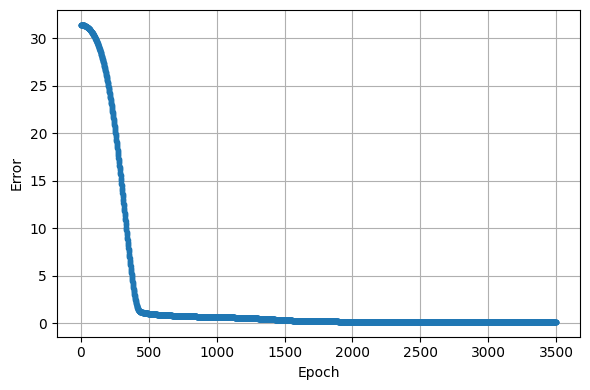

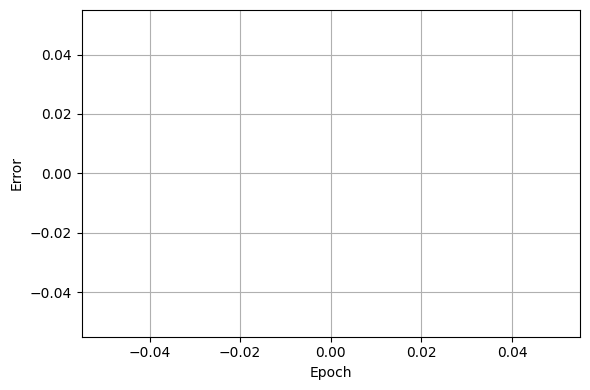

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(loss_lc_avg_arr, marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Error")
# plt.title("Training loss (Adam)")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(loss_cont_avg_arr, marker="o", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Error")
# plt.title("Training loss (Adam)")
plt.grid(True)
plt.tight_layout()
plt.show()

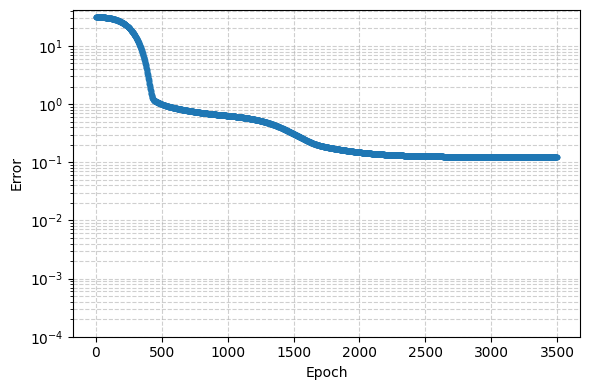

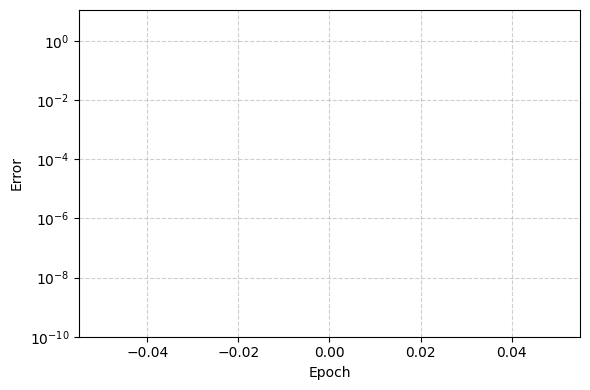

In [24]:
import matplotlib.ticker as mticker
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

plt.plot(loss_lc_avg_arr, marker="o", markersize=3)

plt.yscale("log")  # log-scale y-axis
plt.ylim(bottom=1e-4)

# Format ticks as 10^{-1}, 10^{-2}, ...
ax = plt.gca()
ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

plt.xlabel("Epoch")
plt.ylabel("Error")
# plt.title("Training loss (Adam)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 4))

plt.plot(loss_cont_avg_arr, marker="o", markersize=3)

plt.yscale("log")  # log-scale y-axis
plt.ylim(bottom=1e-10)

# Format ticks as 10^{-1}, 10^{-2}, ...
ax = plt.gca()
ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

plt.xlabel("Epoch")
plt.ylabel("Error")
# plt.title("Training loss (Adam)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

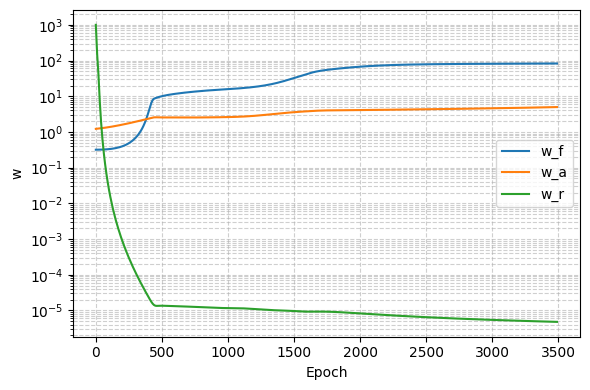

In [25]:
plt.figure(figsize=(6, 4))

plt.plot(np.arange(0,max_epochs,10), w_f_arr, label='w_f')
if num_subdomains > 1:
    plt.plot(np.arange(0,max_epochs,10), w_c_arr, label='w_c')
plt.plot(np.arange(0,max_epochs,10), w_a_arr, label='w_a')
plt.plot(np.arange(0,max_epochs,10), w_r_arr, label='w_r')

plt.yscale("log")  # log-scale y-axis
# plt.ylim(bottom=1e-2)

# Format ticks as 10^{-1}, 10^{-2}, ...
ax = plt.gca()
ax.yaxis.set_major_locator(mticker.LogLocator(base=10))
ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())

plt.xlabel("Epoch")
plt.ylabel("w")
plt.legend()  # Added legend to identify the lines
# plt.title("Training loss (Adam)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [26]:
LCE_CG = []
LCE_rec = []
indices = []

LCE_CG_int = []
LCE_rec_int = []
indices_int = []
for local_cell_idx, cell_verts in enumerate(tqdm(local_cell_vertices)):
    # cell_verts are global vertex indices
    coords = omega_geometry[cell_verts]  # shape (3,2)
    sd = cell_subdomain[local_cell_idx][0]
    net_sd = nets[sd]
    centroid = np.mean(coords, axis=0).reshape(1,-1)
    centroid_t = torch.tensor(centroid, dtype=torch.float32, device=device).squeeze()

    # loc_cells = np.array([[0, 1, 2]], dtype=np.int32)
    loc_cells = np.array([local_cell_idx], dtype=np.int32)

    gdim = coords.shape[1]
    coord_el = basix.ufl.element("Lagrange", "triangle", 1, shape=(gdim,))
    coords_t = torch.tensor(coords, dtype=torch.float32, device=device)
    
    local_gamma_facets = []

    for f in gamma_entities:
        cells = facet_to_cell.links(f)
        if any(c in loc_cells for c in cells):
            local_gamma_facets.append(f)

    # local_mesh = dmesh.create_mesh(
    #     MPI.COMM_SELF,
    #     loc_cells,
    #     coord_el,   # <-- this is the required "e" argument
    #     coords
    # )
    fdim = tdim - 1

    local_mesh, cell_map, vertex_map, geom_map = mesh.create_submesh(omega, tdim, loc_cells)

    omega.topology.create_connectivity(tdim, fdim)
    omega.topology.create_connectivity(fdim, 0)
    local_mesh.topology.create_connectivity(fdim, 0)

    gamma_set = set(np.asarray(gamma_entities, dtype=np.int32))

    # single-cell submesh -> local cell 0
    parent_cell = cell_map.sub_topology_to_topology(
        np.array([0], dtype=np.int32), False
    )[0]

    local_facets = []
    local_values = []

    for lf in range(local_mesh.topology.index_map(fdim).size_local):
        # vertices of local facet in submesh numbering
        lf_vertices_local = local_mesh.topology.connectivity(fdim, 0).links(lf)

        # map submesh vertices -> parent mesh vertices
        lf_vertices_parent = np.sort(
            vertex_map.sub_topology_to_topology(
                np.asarray(lf_vertices_local, dtype=np.int32), False
            )
        )

        matched_parent_facet = None
        for gf in omega.topology.connectivity(tdim, fdim).links(parent_cell):
            gf_vertices = np.sort(
                omega.topology.connectivity(fdim, 0).links(gf)
            )
            if np.array_equal(lf_vertices_parent, gf_vertices):
                matched_parent_facet = gf
                break

        if matched_parent_facet is None:
            raise RuntimeError(f"Could not match local facet {lf} to a parent facet")

        if matched_parent_facet in gamma_set:
            local_facets.append(lf)
            local_values.append(Gamma_tag)

    if len(local_facets) > 0:
        local_facet_tags = mesh.meshtags(
            local_mesh,
            fdim,
            np.array(local_facets, dtype=np.int32),
            np.array(local_values, dtype=np.int32),
        )
    # -------------------------------------------------
    # 2. Local vector CG2 space for r_θ
    # -------------------------------------------------
    # Vector-valued CG2 (shape=(gdim,))
    V_loc = fem.functionspace(local_mesh,("CG", order+1, (gdim,)))
    # r_loc = fem.Function(V_loc)

    # -------------------------------------------------
    # 3. Interpolate NN into r_loc via dof coordinates
    # -------------------------------------------------
    x_loc = V_loc.tabulate_dof_coordinates()[:,0:2]  # (Ndofs, gdim)
    x_loc_torch = torch.tensor(x_loc, dtype=torch.float32)
    
    # -------------------------------------------------
    # 4. Compute ∫_{∂D_j} r_θ · n ds on local mesh
    # -------------------------------------------------
    n_K = ufl.FacetNormal(local_mesh)
    
    edge_indices = [(0, 1), (1, 2), (2, 0)]
    int_r_local = torch.zeros((), device=device)

    num_sub = 3 #sub integral section

    for (i0, i1) in edge_indices:
        x0 = coords_t[i0]
        x1 = coords_t[i1]
        t = x1 - x0
        L = torch.linalg.norm(t)
        if L <= 0:
            continue

        n_edge = (torch.stack([t[1], -t[0]]) / L)
        n_edge = torch.tensor(n_edge, dtype=torch.float32)
        centroid_t = torch.tensor(centroid, dtype=torch.float32, device=device).squeeze()
        midpoint = 0.5 * (x0 + x1)
        if torch.dot(n_edge, centroid_t - midpoint) > 0:
            n_edge = -n_edge
        int_r_local += integrate_edge_flux(net_sd, x0, x1, n_edge, L, xi, wi, num_sub=3)

    # -------------------------------------------------
    # 5. Combine with q_cg and f (precomputed per cell)
    # -------------------------------------------------
    P_loc = fem.functionspace(local_mesh, ("CG", order))
    p_K = fem.Function(P_loc)

    # DOFs on this cell in the global space
    global_dofs = V_m.dofmap.cell_dofs(local_cell_idx)

    # DOFs on the (only) cell in the local space
    local_dofs = P_loc.dofmap.cell_dofs(0)

    p_K.x.array[local_dofs] = p_m.x.array[global_dofs]
    p_K.x.scatter_forward()

    k_m_loc = fem.Function(P_loc)
    k_m_loc.x.array[local_dofs] = k_m.x.array[global_dofs]

    q_CG = -k_m_loc * ufl.grad(p_K)
    int_qcg = fem.assemble_scalar(
                fem.form(ufl.dot(q_CG, n_K) * ufl.ds(domain=local_mesh))
            )   # ∫_{∂D_j} q_cg · n
    
    f_m_loc = fem.Function(P_loc)
    f_m_loc.x.array[local_dofs] = f_m.x.array[global_dofs]
    f_m_loc.x.scatter_forward()
    int_f   = fem.assemble_scalar(fem.form(f_m_loc * ufl.dx(domain=local_mesh)))       # ∫_{D_j} f

    lmbd_loc = fem.functionspace(local_mesh, ("CG", order))
    lmbd_K = fem.Function(lmbd_loc)
    lmbd_K.x.array[local_dofs] = lmbd_bulk.x.array[global_dofs]
    lmbd_K.x.scatter_forward()
    ds_loc = ufl.Measure("ds", domain=local_mesh, subdomain_data=local_facet_tags)

    int_lmbd = fem.assemble_scalar(fem.form(lmbd_K * ds_loc(Gamma_tag)))/2
    # if int_lmbd != 0:
    #     print(int_lmbd)
    residual_j = float(int_r_local) + int_qcg - int_f - int_lmbd
    LCE_CG.append(int_qcg - int_f - int_lmbd)
    LCE_rec.append(residual_j)
    indices.append(local_cell_idx)

    left_dofs_P = fem.locate_dofs_geometrical(
        P_loc, lambda x: np.isclose(x[0], xmin, atol=tol)
    )
    right_dofs_P = fem.locate_dofs_geometrical(
        P_loc, lambda x: np.isclose(x[0], xmax, atol=tol)
    )

    if (len(left_dofs_P) == 0) and (len(right_dofs_P) == 0):
        LCE_CG_int.append(int_qcg - int_f - int_lmbd)
        LCE_rec_int.append(residual_j)
        indices_int.append(local_cell_idx)

  0%|          | 0/2048 [00:00<?, ?it/s]/tmp/ipykernel_4687/2040434653.py:120: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  n_edge = torch.tensor(n_edge, dtype=torch.float32)
100%|██████████| 2048/2048 [00:49<00:00, 40.99it/s]


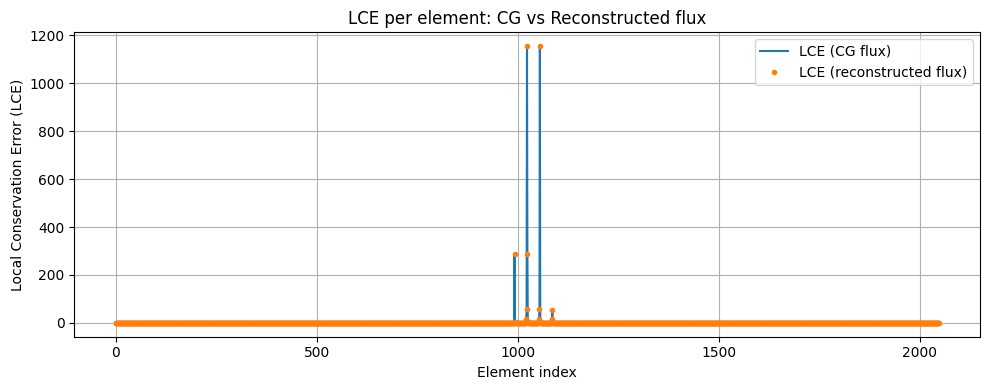

CG LCE stats: {'min': -287.6519629487222, 'max': 1155.2948830320554, 'L1_mean_abs': 1.5363651630295871, 'L2_rms': 37.27236913782731}
Reconstructed LCE stats: {'min': -287.6491885872012, 'max': 1155.296714831801, 'L1_mean_abs': 1.5339708070653946, 'L2_rms': 37.27240696834934}


In [27]:

indices_plot = np.array(indices, dtype=int)
LCE_CG_plot = np.array(LCE_CG, dtype=float)
LCE_rec_plot = np.array(LCE_rec, dtype=float)

# plot
plt.figure(figsize=(10,4))
plt.plot(indices_plot, np.abs(LCE_CG_plot), label="LCE (CG flux)")
plt.plot(indices_plot, np.abs(LCE_rec_plot), ".", label="LCE (reconstructed flux)")
plt.xlabel("Element index")
plt.ylabel("Local Conservation Error (LCE)")
plt.title("LCE per element: CG vs Reconstructed flux")
plt.legend()
plt.grid(True)
plt.tight_layout()
# out_path = "/mnt/data/lce_plot.png"
# plt.savefig(out_path)
plt.show()

# print stats & produce dataframe
def stats(arr):
    return {"min": float(arr.min()), "max": float(arr.max()), "L1_mean_abs": float(np.mean(np.abs(arr))), "L2_rms": float(np.sqrt(np.mean(arr**2)))}
print("CG LCE stats:", stats(LCE_CG_plot))
print("Reconstructed LCE stats:", stats(LCE_rec_plot))

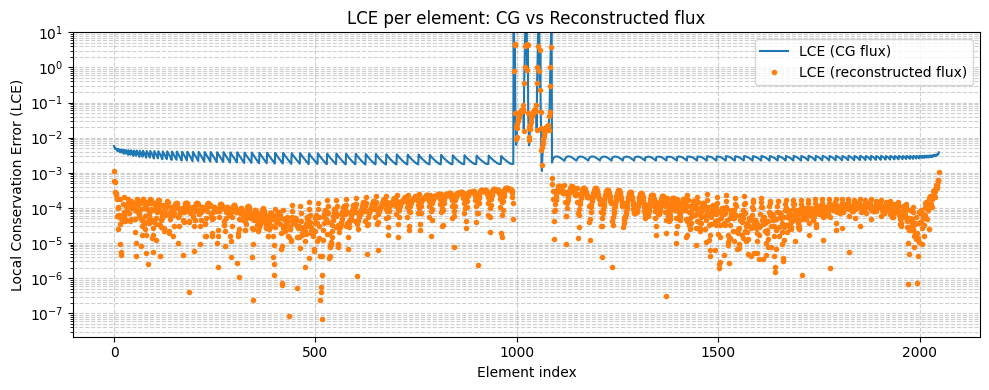

In [30]:
import matplotlib.ticker as mticker

indices_plot = np.array(indices, dtype=int)
LCE_CG_plot = np.array(LCE_CG, dtype=float)
LCE_rec_plot = np.array(LCE_rec, dtype=float)

plt.figure(figsize=(10,4))
plt.plot(indices_plot, np.abs(LCE_CG_plot), label="LCE (CG flux)")
plt.plot(indices_plot, np.abs(LCE_rec_plot), ".", label="LCE (reconstructed flux)")

plt.yscale("log")  # log-scale y-axis
plt.ylim(top=1e1)  # set your desired ymax

# Format ticks as 10^{-1}, 10^{-2}, ...
plt.gca().yaxis.set_major_formatter(mticker.LogFormatterMathtext())
plt.gca().yaxis.set_major_locator(mticker.LogLocator(base=10))

plt.xlabel("Element index")
plt.ylabel("Local Conservation Error (LCE)")
plt.title("LCE per element: CG vs Reconstructed flux")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [33]:
count = np.sum(np.abs(LCE_CG_plot) > 1e-2)
print(count)

84


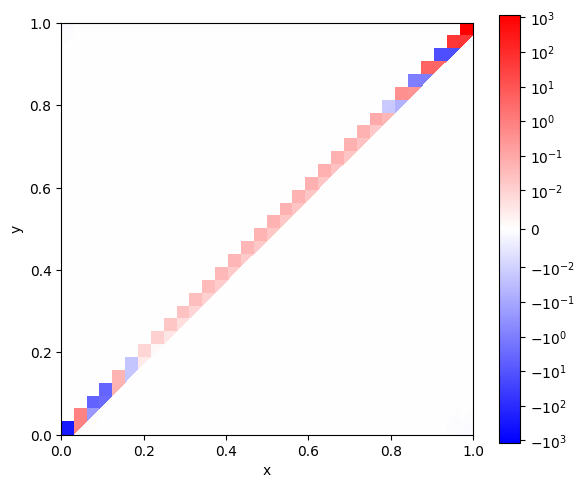

In [36]:
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np

# --- Mesh data ---
coords = omega.geometry.x
cells = omega.topology.connectivity(omega.topology.dim, 0).array.reshape(-1, 3)

# --- DG0 values (cellwise) ---
values = np.zeros(len(cells))
for cell, val in zip(indices, LCE_rec):
    values[cell] = val

# --- Symmetric color scale ---
vmax = np.max(np.abs(LCE_rec))
# vmax = 1
vmin = -vmax

# --- Build triangulation ---
triang = tri.Triangulation(coords[:, 0], coords[:, 1], cells)

from matplotlib.colors import SymLogNorm

linthresh = 1e-2   # threshold around zero (tune this!)

plt.figure(figsize=(6, 5))
tpc = plt.tripcolor(
    triang,
    facecolors=values,
    cmap="bwr",
    norm=SymLogNorm(
        linthresh=linthresh,
        vmin=-vmax,
        vmax=vmax,
        base=10
    ),
    # edgecolors="k",
)

# plt.plot([0,1],[0,1],'r')

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.colorbar(tpc)
plt.gca().set_aspect("equal")
# plt.title("Local Conservation Error (symlog scale)")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()